# Setup

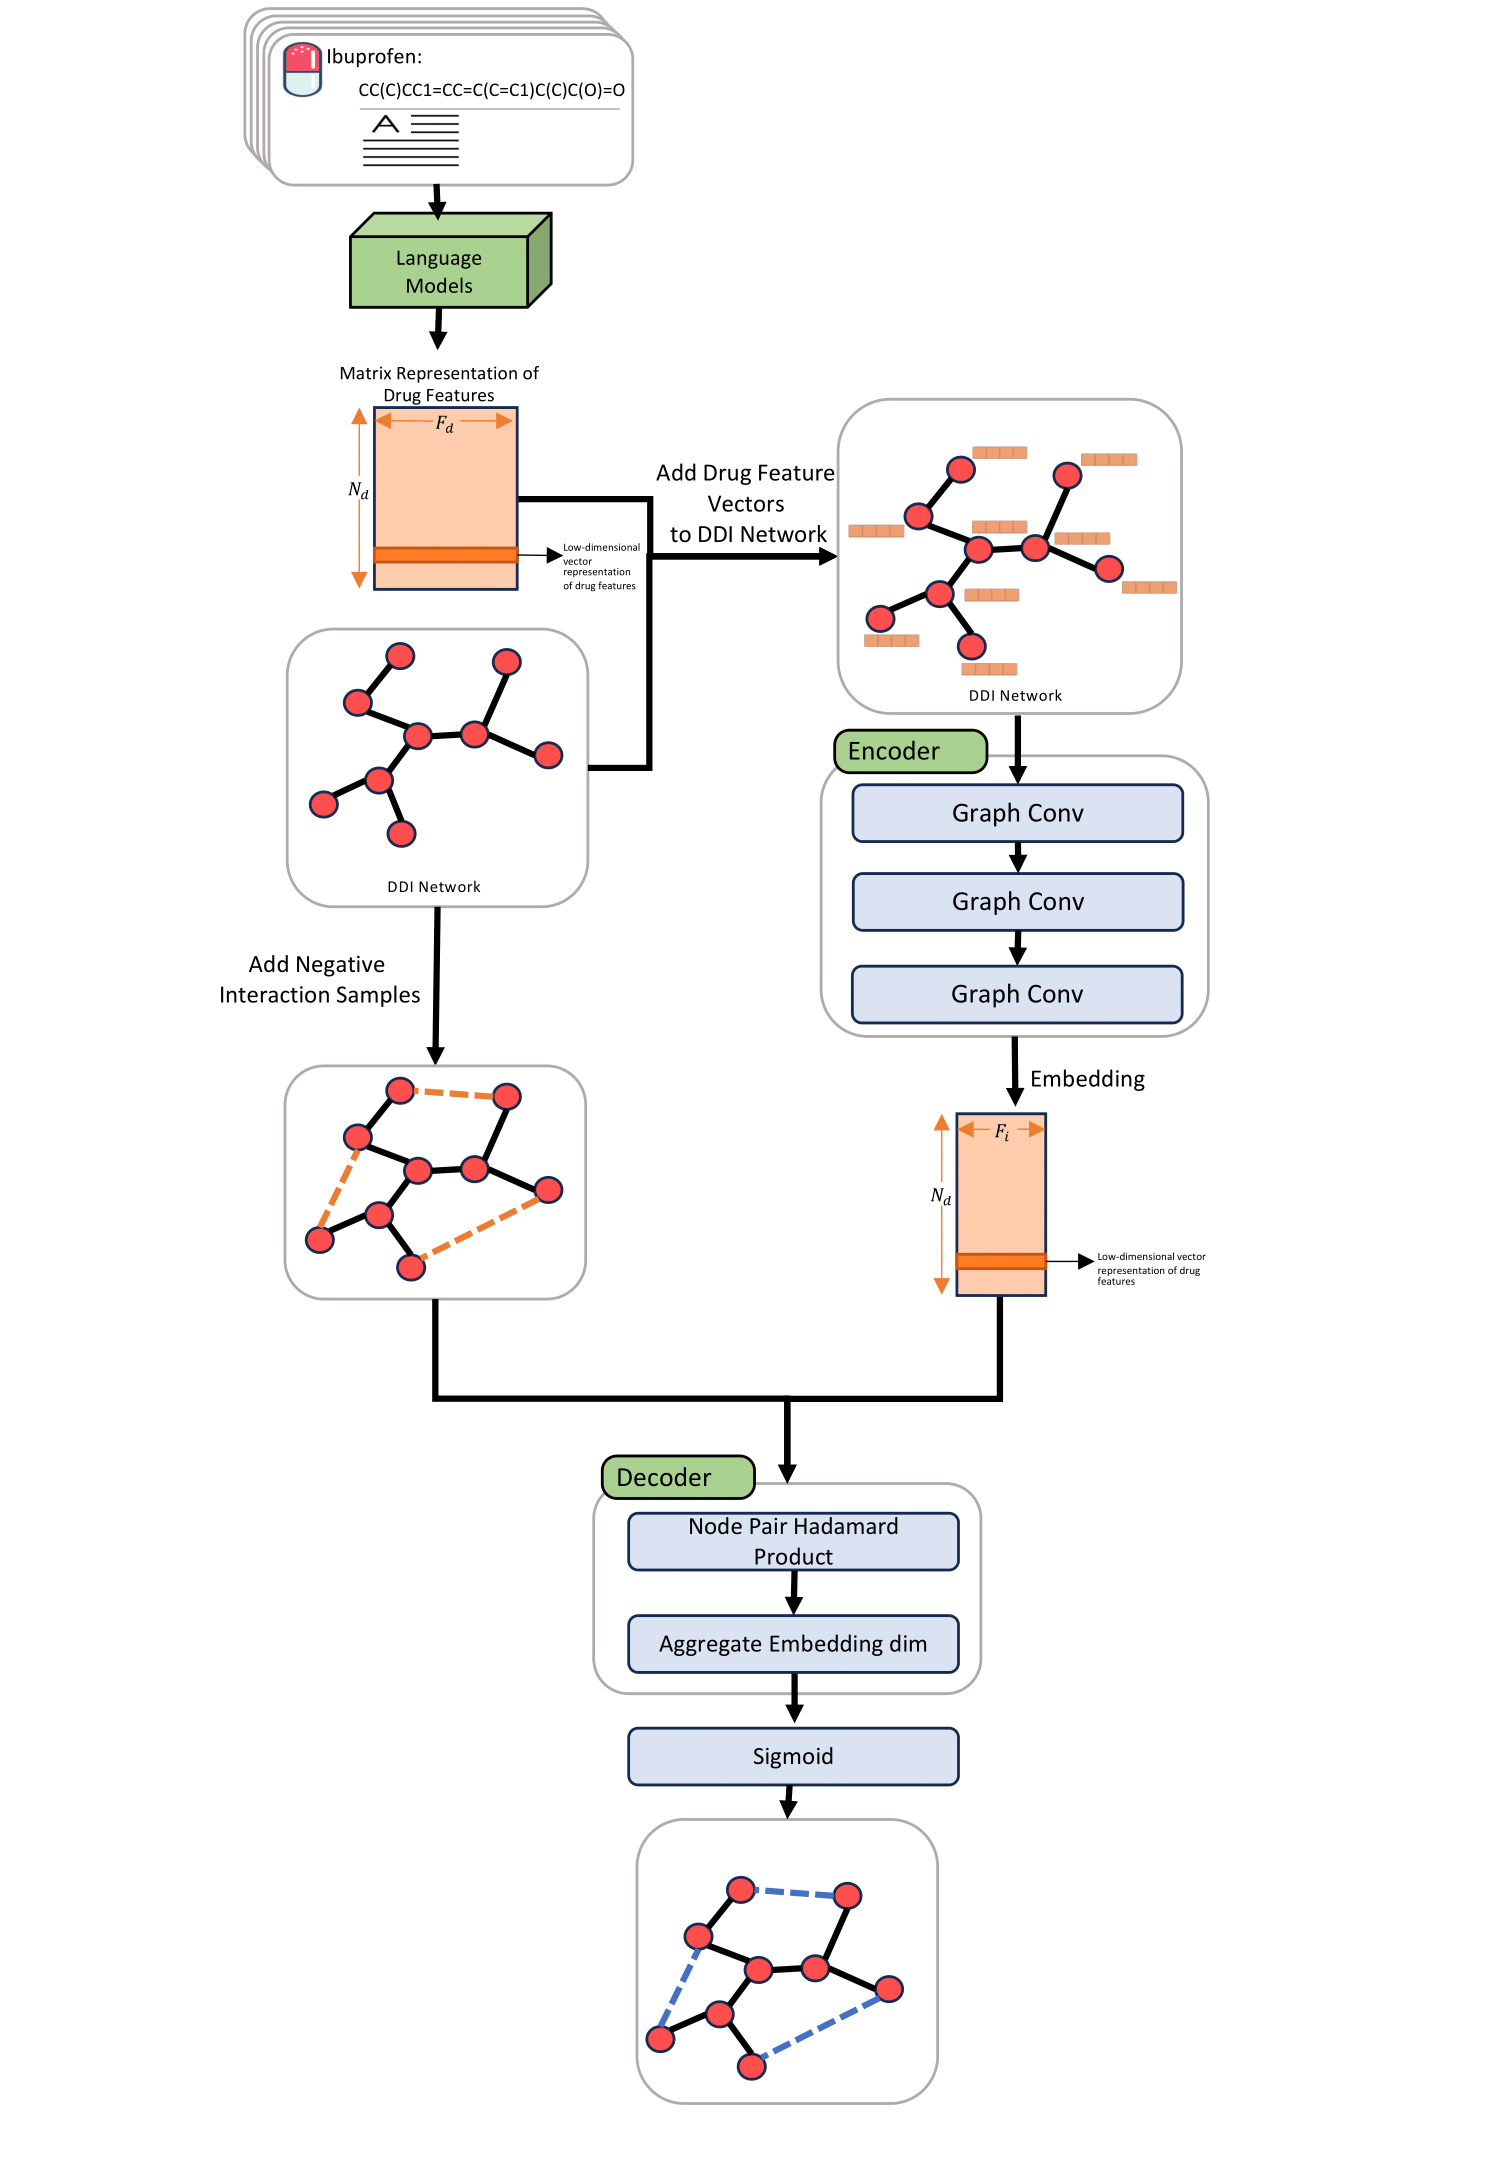

# Experiments

In [2]:
import warnings
import logging

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
from sklearn.manifold import TSNE
from sklearn.metrics import (
    PrecisionRecallDisplay,
    precision_recall_curve,
    confusion_matrix,
    f1_score,
    RocCurveDisplay,
    roc_curve,
)

import plotly.express as px

from ddi_graph_neural_network.train_model import main
from ddi_graph_neural_network.config import Config, LossType


warnings.simplefilter(action="ignore", category=FutureWarning)

pd.set_option('display.max_rows', 100)
pd.set_option('display.max_columns', 50)

## Experiments on Loss Functions and Labels

This section describes how negative examples are constructed for training and the loss configurations evaluated.

Negatives for training

- Sampled negatives: unlabeled pairs (non‑positive edges) are sampled uniformly and treated as negatives for training. This approach assumes most unobserved pairs are true negatives but admits the risk of including unlabelled positives among sampled negatives.

- Observed (validated) negatives: use only the validated negative labels provided in the CRESCENDDI dataset. This produces a smaller negative set; to correct for class imbalance we compensate by weighting the loss rather than inflating the negative sample count.

- Upsampled negatives: augment the observed negatives by sampling with replacement so that the number of negative training examples matches the number of positive examples. This yields a balanced training set but changes the effective data distribution seen during training.

Experimental design

We evaluate combinations of three orthogonal design choices:

1. Loss function: either (a) plain binary cross‑entropy on logits (BCEWithLogitsLoss) or (b) a weighted binary cross‑entropy that scales the positive class contribution by a scalar multiplier.

2. Negative handling: whether negatives are upsampled to balance the training set or the original observed negatives are used.

3. Training negative selection: whether the training set uses only sampled negatives (i.e., sampled from the unlabeled pool) or explicitly uses the validated negatives (controlled by `use_only_sampled_negatives_in_train`).

Weighted binary cross‑entropy

We implement a weighted BCE to compensate for label imbalance. Let $p=\sigma(z)$ be the model probability (sigmoid of the logit $z$), $y\in\{0,1\}$ the true label, and $N_{pos},N_{neg}$ the counts of positive and negative examples used for training. We define a positive‑class scaling factor

$$
\alpha_{pos} = \mathrm{pos\_loss\_multiplier}\;\frac{N_{neg}}{N_{pos}},
$$

and set the negative weight to $\alpha_{neg}=1$. The per‑example weighted binary cross‑entropy is

$$
\mathcal{L}(p,y) = -\alpha_{pos}\,y\,\log p - \alpha_{neg}\,(1-y)\,\log(1-p).
$$

In PyTorch this behaviour is achieved by providing a `pos_weight` parameter to `BCEWithLogitsLoss` (equal to $\alpha_{pos}$ above), which multiplies the loss contribution of positive examples.

Focal loss (note)

The binary focal loss modifies cross‑entropy with a focusing term and is defined as

$$
\mathrm{FL}(p_t) = -\alpha\,(1-p_t)^{\gamma}\,\log(p_t),
$$

where $p_t$ is the model probability for the true class, $\alpha$ balances classes, and $\gamma\ge 0$ focuses training on hard examples. When $\gamma=0$ the focal loss reduces to a (possibly weighted) cross‑entropy. In our hyperparameter search the best focal parameter collapsed to $\gamma\approx 0$, so focal loss provided no empirical advantage over the weighted BCE in this task.

Summary of empirical finding

Across the tested combinations, preserving the empirical negative prevalence (using observed negatives) while compensating for imbalance via loss weighting produced the best generalisation (ROC and PR). Upsampling negatives to force class balance did not improve, and in some cases reduced, validation performance. The optimized positive multiplier used in our experiments was approximately $0.5$ (reported in the results tables and figures), consistent with the weighting rule above.

The following cells run the selected configurations and collect ROC and PR curves, reporting means and standard deviations when repetitions are used.

In [3]:
logging.basicConfig(level=logging.DEBUG, format="%(asctime)s - %(levelname)s - %(message)s")
logging.getLogger().setLevel(logging.DEBUG)

config = Config()

config.training.seed = 42
config.graph.seed_graph_sampling = 42
config.graph.current_graph = "DrugBank_CRESCENDDI"
config.run.take_negative_samples = True
config.training.repetitions = 5
config.graph.feature = "DESC_GPT"

### Optimizing individual losses

In [124]:
settings = [
{
    "loss_type": LossType.BCEWithLogitsLoss,
    "pos_loss_multiplier": 1,
    "upsample_negative_labels": True,
    "use_only_sampled_negatives_in_train": False,
},
{
    "loss_type": LossType.BCEWithLogitsLoss,
    "pos_loss_multiplier": 1,
    "upsample_negative_labels": True,
    "use_only_sampled_negatives_in_train": True,
},
{
    "loss_type": LossType.WeightedBCEWithLogitsLoss,
    "pos_loss_multiplier": 0.5,
    "upsample_negative_labels": True,
    "use_only_sampled_negatives_in_train": False,
},
{
    "loss_type": LossType.WeightedBCEWithLogitsLoss,
    "pos_loss_multiplier": 0.5,
    "upsample_negative_labels": True,
    "use_only_sampled_negatives_in_train": True,
},
{
    "loss_type": LossType.WeightedBCEWithLogitsLoss,
    "pos_loss_multiplier": 0.5,
    "upsample_negative_labels": False,
    "use_only_sampled_negatives_in_train": False,
},
{
    "loss_type": LossType.WeightedBCEWithLogitsLoss,
    "pos_loss_multiplier": 0.5,
    "upsample_negative_labels": False,
    "use_only_sampled_negatives_in_train": True,
},
]


In [125]:
import pandas as pd

pd.set_option('display.float_format', lambda x: f'{x:.4f}')

train_setttings = [
    (2272, 27794),
    (0, 30066),
    (2272, 27794),
    (0, 30066),
    (2272, 0),
    (0, 2272)
]
n_pos_train = 30066
train_setttings_df = pd.DataFrame(train_setttings, columns=['Observed Negatives in Train', 'Sampled Negatives in Train'])
train_setttings_df['Observed Positives in Train'] = n_pos_train
train_setttings_df['Positive Loss Multiplier'] = [r['pos_loss_multiplier'] for r in settings]
train_setttings_df['Loss Function'] = [str(r['loss_type']).split('.')[-1] for r in settings]
train_setttings_df['Weight Factor Negative Loss'] = n_pos_train / ( (train_setttings_df['Observed Negatives in Train'] + train_setttings_df['Sampled Negatives in Train']) * train_setttings_df['Positive Loss Multiplier'])
train_setttings_df = train_setttings_df[['Loss Function', 'Observed Positives in Train', 'Observed Negatives in Train', 'Sampled Negatives in Train', 'Weight Factor Negative Loss']]
train_setttings_df.index = [f"S{i+1}" for i in range(len(train_setttings_df))]
train_setttings_df

# display as markdown
from IPython.display import Markdown, display
md = train_setttings_df.to_markdown()
display(Markdown("### Training Set Configurations\n\n" + md))


### Training Set Configurations

|    | Loss Function             |   Observed Positives in Train |   Observed Negatives in Train |   Sampled Negatives in Train |   Weight Factor Negative Loss |
|:---|:--------------------------|------------------------------:|------------------------------:|-----------------------------:|------------------------------:|
| S1 | BCEWithLogitsLoss         |                         30066 |                          2272 |                        27794 |                        1      |
| S2 | BCEWithLogitsLoss         |                         30066 |                             0 |                        30066 |                        1      |
| S3 | WeightedBCEWithLogitsLoss |                         30066 |                          2272 |                        27794 |                        2      |
| S4 | WeightedBCEWithLogitsLoss |                         30066 |                             0 |                        30066 |                        2      |
| S5 | WeightedBCEWithLogitsLoss |                         30066 |                          2272 |                            0 |                       26.4665 |
| S6 | WeightedBCEWithLogitsLoss |                         30066 |                             0 |                         2272 |                       26.4665 |

In [126]:
# Set how many repetitions to run for each configuration (adjust as desired)

results_list = []
for setting in settings:
    config.run.loss_type = setting["loss_type"]
    config.run.pos_loss_multiplier = setting["pos_loss_multiplier"]
    config.run.upsample_negative_labels = setting.get("upsample_negative_labels", False)
    config.run.use_only_sampled_negatives_in_train = setting.get("use_only_sampled_negatives_in_train", False)

    name = f"{setting['loss_type'].name}|mult={setting['pos_loss_multiplier']}|ups={setting.get('upsample_negative_labels', False)}|only_sampled={setting.get('use_only_sampled_negatives_in_train', False)}|reps={repetitions}"
    print(f"=== Running: {name} ===")

    run = main(config)

    y_true = np.asarray(run["label"])  # shape (N,)
    y_scores = np.asarray(run["test_scores"])  # shape (N,)
    metrics = run["metrics"]

    # Extract mean/std from metrics (train `main` returns mean/std when repetitions>1)
    roc_mean = metrics.get("AUC_mean", metrics.get("AUC", None))
    roc_std = metrics.get("AUC_std", None)
    pr_mean = metrics.get("PR_AUC_mean", metrics.get("PR_AUC", None))
    pr_std = metrics.get("PR_AUC_std", None)

    precision, recall, pr_thresh = precision_recall_curve(y_true, y_scores)
    fpr, tpr, roc_thresh = roc_curve(y_true, y_scores)

    results_list.append(
        {
            "name": name,
            "setting": setting,
            "metrics": metrics,
            "ROC_AUC_mean": float(roc_mean) if roc_mean is not None else None,
            "ROC_AUC_std": float(roc_std) if roc_std is not None else None,
            "PR_AUC_mean": float(pr_mean) if pr_mean is not None else None,
            "PR_AUC_std": float(pr_std) if pr_std is not None else None,
            "precision": precision,
            "recall": recall,
            "pr_thresh": pr_thresh,
            "fpr": fpr,
            "tpr": tpr,
            "roc_thresh": roc_thresh,
            "y_true": y_true,
            "y_scores": y_scores,
        }
    )

# Expose results for downstream cells
settings_results = results_list


2026-04-12 12:23:37,661 - DEBUG - Loading CSV graph: DrugBank_CRESCENDDI


=== Running: BCEWithLogitsLoss|mult=1|ups=True|only_sampled=False|reps=1 ===


2026-04-12 12:23:40,353 - DEBUG - Graph and Embeddings Intersection Summary:
Number of drugs in graph: 1516, 
Number of embedding drugs in graph: 1516, 
Number of drugs dropped from graph (not in embeddings): 23, 
Number of embedding drugs not in graph: 7207
Kept percentage of embedding drugs not in graph: 0.0%, 

2026-04-12 12:23:40,419 - DEBUG - Final graph has 1516 nodes and 53892 edges.
Positive edges: 50108, 
Negative edges: 3784
2026-04-12 12:23:40,421 - DEBUG - Run 1/5 for DESC_GPT | LR: 0.0003


======== DESC_GPT ========


2026-04-12 12:23:40,643 - DEBUG - Sampling 27794 negative edges to add to training data.
2026-04-12 12:23:40,646 - DEBUG - After upsampling, training data has 30066 positive and 30066 negative samples.
2026-04-12 12:24:02,162 - DEBUG - Early stopping at epoch 64
2026-04-12 12:24:02,169 - DEBUG - Run 2/5 for DESC_GPT | LR: 0.0003
2026-04-12 12:24:02,367 - DEBUG - Sampling 27794 negative edges to add to training data.
2026-04-12 12:24:02,371 - DEBUG - After upsampling, training data has 30066 positive and 30066 negative samples.
2026-04-12 12:24:32,555 - DEBUG - Run 3/5 for DESC_GPT | LR: 0.0003
2026-04-12 12:24:32,758 - DEBUG - Sampling 27794 negative edges to add to training data.
2026-04-12 12:24:32,762 - DEBUG - After upsampling, training data has 30066 positive and 30066 negative samples.
2026-04-12 12:25:06,753 - DEBUG - Early stopping at epoch 91
2026-04-12 12:25:06,769 - DEBUG - Run 4/5 for DESC_GPT | LR: 0.0003
2026-04-12 12:25:06,973 - DEBUG - Sampling 27794 negative edges to a

...

-------------------------------
-- FINAL RESULTS FOR GRAPH DrugBank_CRESCENDDI | FEATURE DESC_GPT -- 
Graph Data:  DrugBank_CRESCENDDI
ROC_AUC: 0.7744
PR_AUC: 0.9765
std ROC_AUC: 0.0051
std PR_AUC: 0.0006
repetitions: 5
-------------------------------
=== Running: WeightedBCEWithLogitsLoss|mult=0.5|ups=False|only_sampled=True|reps=1 ===


2026-04-12 12:31:50,245 - DEBUG - Graph and Embeddings Intersection Summary:
Number of drugs in graph: 1516, 
Number of embedding drugs in graph: 1516, 
Number of drugs dropped from graph (not in embeddings): 23, 
Number of embedding drugs not in graph: 7207
Kept percentage of embedding drugs not in graph: 0.0%, 

2026-04-12 12:31:50,315 - DEBUG - Final graph has 1516 nodes and 53892 edges.
Positive edges: 50108, 
Negative edges: 3784
2026-04-12 12:31:50,319 - DEBUG - Run 1/5 for DESC_GPT | LR: 0.0003
2026-04-12 12:31:50,346 - DEBUG - Dropped negative samples from training data. Training data now has 30066.0 positive samples and 0 negative samples.


======== DESC_GPT ========


2026-04-12 12:31:50,535 - DEBUG - Sampling 2272 negative edges to add to training data.
2026-04-12 12:31:50,539 - DEBUG - After upsampling, training data has 30066 positive and 2272 negative samples.
2026-04-12 12:31:50,548 - DEBUG - Using imbalanced loss with pos_weight: 0.0378
2026-04-12 12:31:59,847 - DEBUG - Early stopping at epoch 28
2026-04-12 12:31:59,860 - DEBUG - Run 2/5 for DESC_GPT | LR: 0.0003
2026-04-12 12:31:59,878 - DEBUG - Dropped negative samples from training data. Training data now has 30066.0 positive samples and 0 negative samples.
2026-04-12 12:32:00,066 - DEBUG - Sampling 2272 negative edges to add to training data.
2026-04-12 12:32:00,069 - DEBUG - After upsampling, training data has 30066 positive and 2272 negative samples.
2026-04-12 12:32:00,081 - DEBUG - Using imbalanced loss with pos_weight: 0.0378
2026-04-12 12:32:12,276 - DEBUG - Early stopping at epoch 32
2026-04-12 12:32:12,284 - DEBUG - Run 3/5 for DESC_GPT | LR: 0.0003
2026-04-12 12:32:12,302 - DEBUG 

-------------------------------
-- FINAL RESULTS FOR GRAPH DrugBank_CRESCENDDI | FEATURE DESC_GPT -- 
Graph Data:  DrugBank_CRESCENDDI
ROC_AUC: 0.7427
PR_AUC: 0.9717
std ROC_AUC: 0.0104
std PR_AUC: 0.0014
repetitions: 5
-------------------------------


In [127]:
# Recreate concise short codes and display legend
from IPython.display import Markdown, display

short_codes = {}
descriptions = []
for i, r in enumerate(settings_results):
    code = f"S{i+1}"
    short_codes[r['name']] = code
    desc = f"{r['setting']['loss_type'].name}, pos_mult={r['setting']['pos_loss_multiplier']}, upsample={r['setting']['upsample_negative_labels']}"
    descriptions.append((code, r['name'], desc))

md = "| Code | Short Name | Details |\n|---|---:|---|\n"
for code, name, desc in descriptions:
    md += f"| **{code}** | `{name}` | {desc} |\n"

display(Markdown("### Settings Legend\n\n" + md))

# Expose mappings for plotting cells
settings_short_codes = short_codes
settings_short_desc = {code: desc for code, _, desc in descriptions}

print('Legend created. Use `settings_short_codes` and `settings_short_desc` in subsequent cells.')

### Settings Legend

| Code | Short Name | Details |
|---|---:|---|
| **S1** | `BCEWithLogitsLoss|mult=1|ups=True|only_sampled=False|reps=1` | BCEWithLogitsLoss, pos_mult=1, upsample=True |
| **S2** | `BCEWithLogitsLoss|mult=1|ups=True|only_sampled=True|reps=1` | BCEWithLogitsLoss, pos_mult=1, upsample=True |
| **S3** | `WeightedBCEWithLogitsLoss|mult=0.5|ups=True|only_sampled=False|reps=1` | WeightedBCEWithLogitsLoss, pos_mult=0.5, upsample=True |
| **S4** | `WeightedBCEWithLogitsLoss|mult=0.5|ups=True|only_sampled=True|reps=1` | WeightedBCEWithLogitsLoss, pos_mult=0.5, upsample=True |
| **S5** | `WeightedBCEWithLogitsLoss|mult=0.5|ups=False|only_sampled=False|reps=1` | WeightedBCEWithLogitsLoss, pos_mult=0.5, upsample=False |
| **S6** | `WeightedBCEWithLogitsLoss|mult=0.5|ups=False|only_sampled=True|reps=1` | WeightedBCEWithLogitsLoss, pos_mult=0.5, upsample=False |


Legend created. Use `settings_short_codes` and `settings_short_desc` in subsequent cells.


### Settings Legend

| Code | Description |
|---|---|
| **S1** | BCEWithLogitsLoss, pos_mult=1, upsample=True |
| **S2** | BCEWithLogitsLoss, pos_mult=1, upsample=True |
| **S3** | WeightedBCEWithLogitsLoss, pos_mult=0.5, upsample=True |
| **S4** | WeightedBCEWithLogitsLoss, pos_mult=0.5, upsample=True |
| **S5** | WeightedBCEWithLogitsLoss, pos_mult=0.5, upsample=False |
| **S6** | WeightedBCEWithLogitsLoss, pos_mult=0.5, upsample=False |


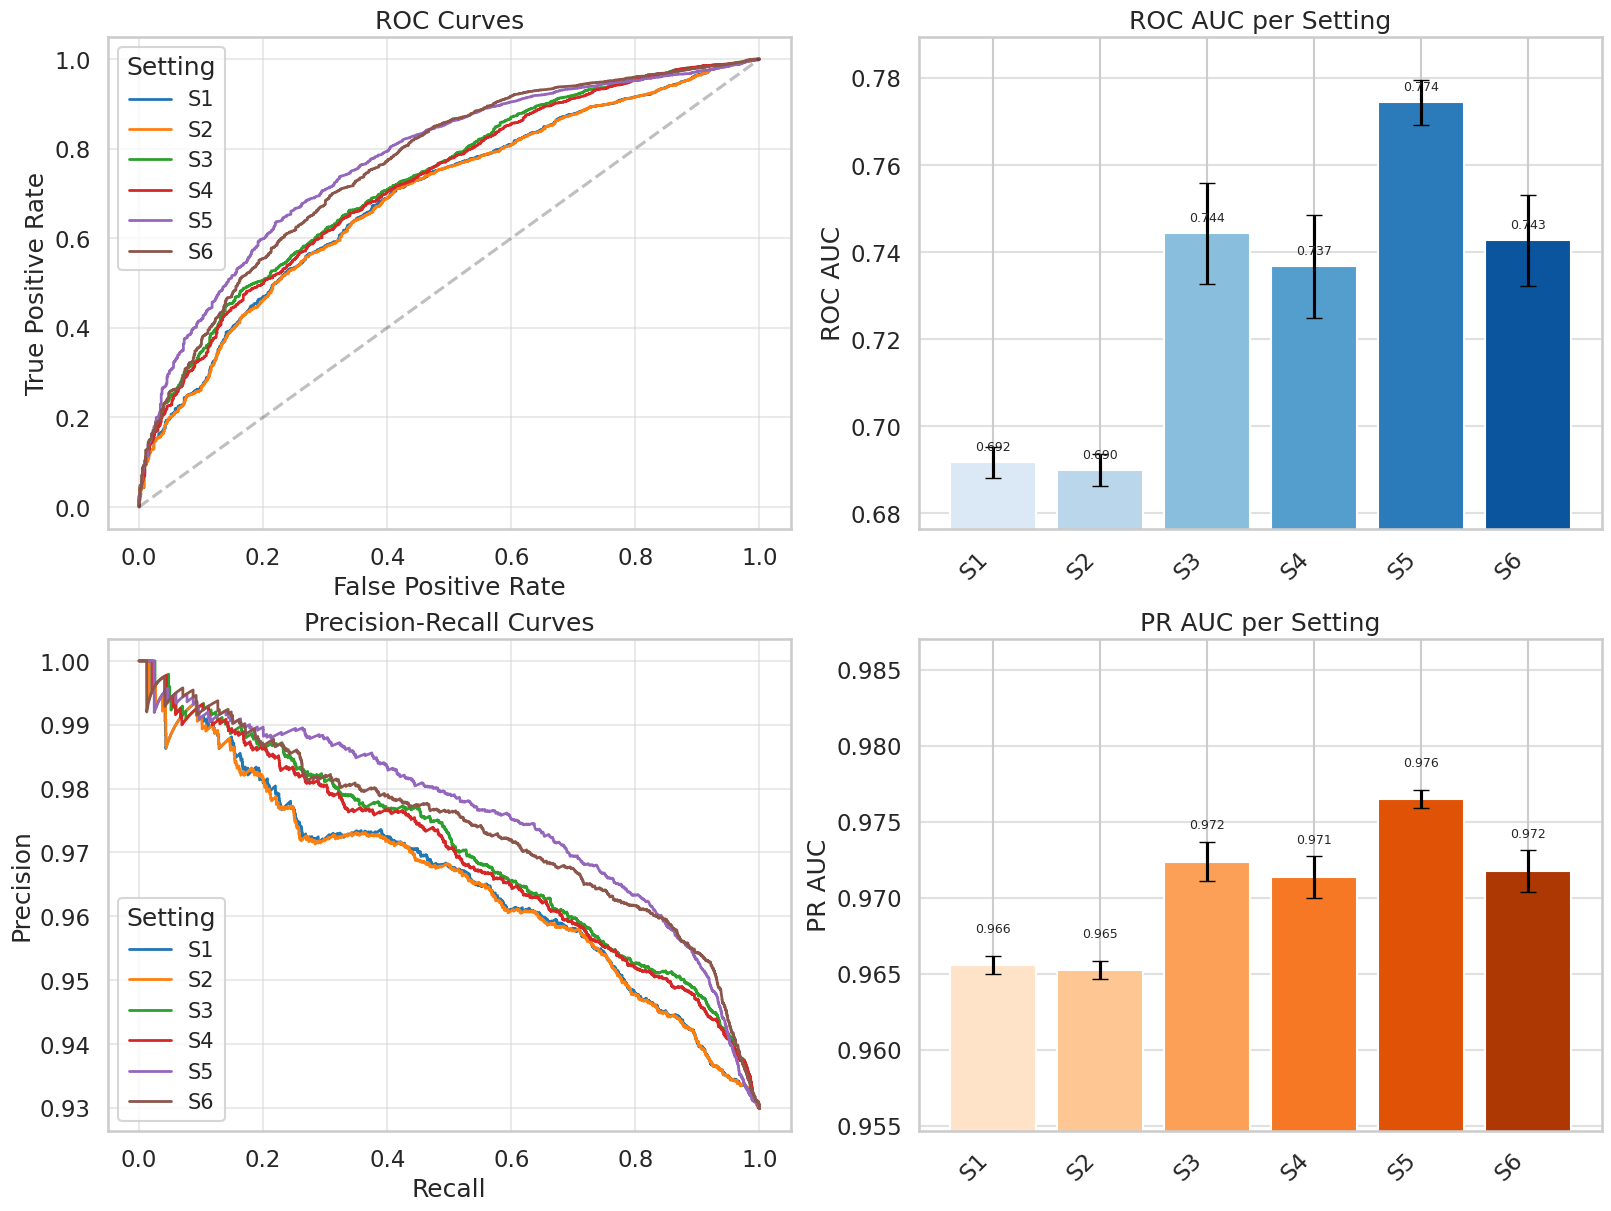

Saved combined report grid to: /home/giobbi/DDI_LLM_repo/DDI_with_ML/analysis/analysis_results_figs/report_grid.png
Saved summary CSV to: /home/giobbi/DDI_LLM_repo/DDI_with_ML/analysis/analysis_results_figs/settings_summary.csv


In [128]:
# Consolidated report: 2x2 grid (ROC curves | ROC AUC) / (PR curves | PR AUC)
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from IPython.display import Markdown, display

sns.set_style('whitegrid')
sns.set_context('talk')

# Build summary DataFrame
rows = []
for r in settings_results:
    rows.append(
        {
            "name": r["name"],
            "short": settings_short_codes.get(r["name"], r["name"]),
            "loss_type": r["setting"]["loss_type"].name,
            "pos_loss_multiplier": r["setting"]["pos_loss_multiplier"],
            "upsample_negative_labels": r["setting"]["upsample_negative_labels"],
            "ROC_AUC_mean": r.get("ROC_AUC_mean", np.nan),
            "ROC_AUC_std": r.get("ROC_AUC_std", 0) if r.get("ROC_AUC_std", None) is not None else 0,
            "PR_AUC_mean": r.get("PR_AUC_mean", np.nan),
            "PR_AUC_std": r.get("PR_AUC_std", 0) if r.get("PR_AUC_std", None) is not None else 0,
            "precision": r.get('precision'),
            "recall": r.get('recall'),
            "fpr": r.get('fpr'),
            "tpr": r.get('tpr'),
        }
    )

summary_df = pd.DataFrame(rows)
summary_df = summary_df.sort_values('short')

# Display concise legend
legend_md = "### Settings Legend\n\n" + "| Code | Description |\n|---|---|\n"
for code, desc in settings_short_desc.items():
    legend_md += f"| **{code}** | {desc} |\n"
display(Markdown(legend_md))

# Create figure directory
fig_dir = os.path.join(os.getcwd(), "analysis_results_figs")
os.makedirs(fig_dir, exist_ok=True)

labels = summary_df['short'].to_list()
indices = np.arange(len(labels))

# Helper to compute y limits with offset
def compute_ylim_with_offset(means, errs=None, min_range=0.03):
    means = np.asarray(means, dtype=float)
    errs = np.zeros_like(means) if errs is None else np.asarray(errs, dtype=float)
    valid = ~np.isnan(means)
    if not valid.any():
        return 0.0, 1.0
    min_val = np.nanmin(means[valid] - errs[valid])
    max_val = np.nanmax(means[valid] + errs[valid])
    data_range = max_val - min_val
    margin = max(0.01, 0.06 * data_range)
    lower = max(0.0, min_val - margin)
    upper = min(1.0, max_val + margin)
    if (upper - lower) < min_range:
        upper = min(1.0, lower + min_range)
        lower = max(0.0, upper - min_range)
    return lower, upper

# Prepare arrays for bars
roc_means = summary_df['ROC_AUC_mean'].to_numpy(dtype=float)
roc_err = summary_df['ROC_AUC_std'].to_numpy(dtype=float)
pr_means = summary_df['PR_AUC_mean'].to_numpy(dtype=float)
pr_err = summary_df['PR_AUC_std'].to_numpy(dtype=float)

roc_low, roc_hi = compute_ylim_with_offset(roc_means, roc_err)
pr_low, pr_hi = compute_ylim_with_offset(pr_means, pr_err)

# Create 2x2 grid
fig, axes = plt.subplots(2, 2, figsize=(16, 12), constrained_layout=True)
(ax_roc_curve, ax_roc_bar), (ax_pr_curve, ax_pr_bar) = axes

# Top-left: ROC curves (no numeric values in legend)
for _, row in summary_df.iterrows():
    short = row['short']
    mask = [r for r in settings_results if settings_short_codes.get(r['name']) == short]
    if mask:
        r = mask[0]
        ax_roc_curve.plot(r['fpr'], r['tpr'], label=short, linewidth=2)
ax_roc_curve.plot([0,1],[0,1],'k--', alpha=0.25)
ax_roc_curve.set_title('ROC Curves')
ax_roc_curve.set_xlabel('False Positive Rate')
ax_roc_curve.set_ylabel('True Positive Rate')
ax_roc_curve.grid(alpha=0.4)
ax_roc_curve.legend(title='Setting', fontsize='small')

# Top-right: ROC AUC bar
bars_roc = ax_roc_bar.bar(indices, roc_means, yerr=roc_err, capsize=6, color=sns.color_palette('Blues', n_colors=len(labels)))
ax_roc_bar.set_xticks(indices)
ax_roc_bar.set_xticklabels(labels, rotation=45, ha='right')
ax_roc_bar.set_ylim(roc_low, roc_hi)
ax_roc_bar.set_title('ROC AUC per Setting')
ax_roc_bar.set_ylabel('ROC AUC')
ax_roc_bar.grid(axis='y', alpha=0.6)
for rect in bars_roc:
    h = rect.get_height()
    ax_roc_bar.text(rect.get_x() + rect.get_width()/2., h + 0.002, f"{h:.3f}", ha='center', va='bottom', fontsize=9)

# Bottom-left: Precision-Recall curves (no numeric values in legend)
for _, row in summary_df.iterrows():
    short = row['short']
    mask = [r for r in settings_results if settings_short_codes.get(r['name']) == short]
    if mask:
        r = mask[0]
        ax_pr_curve.plot(r['recall'], r['precision'], label=short, linewidth=2)
ax_pr_curve.set_title('Precision-Recall Curves')
ax_pr_curve.set_xlabel('Recall')
ax_pr_curve.set_ylabel('Precision')
ax_pr_curve.grid(alpha=0.4)
ax_pr_curve.legend(title='Setting', fontsize='small', loc='lower left')

# Bottom-right: PR AUC bar
bars_pr = ax_pr_bar.bar(indices, pr_means, yerr=pr_err, capsize=6, color=sns.color_palette('Oranges', n_colors=len(labels)))
ax_pr_bar.set_xticks(indices)
ax_pr_bar.set_xticklabels(labels, rotation=45, ha='right')
ax_pr_bar.set_ylim(pr_low, pr_hi)
ax_pr_bar.set_title('PR AUC per Setting')
ax_pr_bar.set_ylabel('PR AUC')
ax_pr_bar.grid(axis='y', alpha=0.6)
for rect in bars_pr:
    h = rect.get_height()
    ax_pr_bar.text(rect.get_x() + rect.get_width()/2., h + 0.002, f"{h:.3f}", ha='center', va='bottom', fontsize=9)

# Save combined report figure
report_path = os.path.join(fig_dir, 'report_grid.png')
fig.savefig(report_path, dpi=180)
plt.show()
print(f"Saved combined report grid to: {report_path}")

# Also save summary CSV
summary_csv = os.path.join(fig_dir, 'settings_summary.csv')
summary_df.to_csv(summary_csv, index=False)
print(f"Saved summary CSV to: {summary_csv}")

Outcome:

- Switchting from BCE to Weighted improves performance with a near optimal factor of pos_loss_multiplier = 0.5

- using the true observed negative labels as learning signal improves performance to the pendent where this nubmer is sampled.
- The setting where only the true observed negatives are used and the class imbalance is tackled via the weighted loss function performs clearly the best. this indicates that the true negatives indeed deliver a stronger learning signal.


In [129]:
results_df = pd.DataFrame(settings_results)[['name', 'ROC_AUC_mean', 'ROC_AUC_std', 'PR_AUC_mean', 'PR_AUC_std']]
# set index to short code
results_df['Run Setting'] = results_df['name'].map(settings_short_codes)
results_df = results_df.set_index('Run Setting')
results_df = results_df[['ROC_AUC_mean', 'ROC_AUC_std', 'PR_AUC_mean', 'PR_AUC_std']]
# display as markdown
md = results_df.to_markdown()
display(Markdown("### Summary of Metrics\n\n" + md))


### Summary of Metrics

| Run Setting   |   ROC_AUC_mean |   ROC_AUC_std |   PR_AUC_mean |   PR_AUC_std |
|:--------------|---------------:|--------------:|--------------:|-------------:|
| S1            |       0.691743 |    0.0036265  |      0.965549 |  0.000594783 |
| S2            |       0.689967 |    0.00358461 |      0.965221 |  0.000580917 |
| S3            |       0.744292 |    0.0115167  |      0.972379 |  0.00131011  |
| S4            |       0.736691 |    0.0117834  |      0.97137  |  0.00138156  |
| S5            |       0.774351 |    0.00508484 |      0.97647  |  0.000587626 |
| S6            |       0.742682 |    0.0104134  |      0.971744 |  0.001369    |

## Experiment of Embeddings

In [6]:
logging.basicConfig(level=logging.DEBUG, format="%(asctime)s - %(levelname)s - %(message)s")
logging.getLogger().setLevel(logging.DEBUG)

config = Config()

config.training.seed = 42
config.graph.seed_graph_sampling = 41
config.graph.current_graph = "DrugBank_CRESCENDDI"
config.run.take_negative_samples = True
config.run.loss_type = LossType.WeightedBCEWithLogitsLoss
config.run.pos_loss_multiplier = 0.5
config.run.upsample_negative_labels = False
config.run.use_only_sampled_negatives_in_train = False

config.training.repetitions = 1

In [7]:
settings = [{
    "feature": "__ONES__",
},
{
    "feature": "DESC_GPT",
},
]

In [8]:
# Feature experiments: collect metrics and produce the same 2x2 report grid as for loss experiments
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import precision_recall_curve, roc_curve
from IPython.display import Markdown, display

sns.set_style('whitegrid')
sns.set_context('talk')

feature_results = []
for setting in settings:
    feature = setting.get('feature')
    config.graph.feature = feature
    name = f"Feature|{feature}"
    print(f"=== Running: {name} ===")

    run = main(config)
    y_true = np.asarray(run['label'])
    y_scores = np.asarray(run['test_scores'])
    metrics = run['metrics']

    roc_mean = metrics.get('AUC_mean', metrics.get('AUC', None))
    roc_std = metrics.get('AUC_std', None)
    pr_mean = metrics.get('PR_AUC_mean', metrics.get('PR_AUC', None))
    pr_std = metrics.get('PR_AUC_std', None)

    precision, recall, pr_thresh = precision_recall_curve(y_true, y_scores)
    fpr, tpr, roc_thresh = roc_curve(y_true, y_scores)

    feature_results.append({
        'name': name,
        'feature': feature,
        'metrics': metrics,
        'ROC_AUC_mean': float(roc_mean) if roc_mean is not None else np.nan,
        'ROC_AUC_std': float(roc_std) if roc_std is not None else 0.0,
        'PR_AUC_mean': float(pr_mean) if pr_mean is not None else np.nan,
        'PR_AUC_std': float(pr_std) if pr_std is not None else 0.0,
        'precision': precision,
        'recall': recall,
        'pr_thresh': pr_thresh,
        'fpr': fpr,
        'tpr': tpr,
        'y_true': y_true,
        'y_scores': y_scores,
    })


2026-04-13 08:47:16,258 - DEBUG - Loading CSV graph: DrugBank_CRESCENDDI


2026-04-13 08:47:16,452 - DEBUG - Final graph has 1539 nodes and 54892 edges.
Positive edges: 51108, 
Negative edges: 3784


=== Running: Feature|__ONES__ ===


2026-04-13 08:47:16,455 - DEBUG - Run 1/1 for __ONES__ | LR: 0.0003
2026-04-13 08:47:16,515 - DEBUG - Using imbalanced loss with pos_weight: 0.0370


======== __ONES__ ========


...

-------------------------------
-- FINAL RESULTS FOR GRAPH DrugBank_CRESCENDDI | FEATURE __ONES__ -- 
Graph Data:  DrugBank_CRESCENDDI
ROC_AUC: 0.6644
PR_AUC: 0.9614
=== Running: Feature|DESC_GPT ===


2026-04-13 08:47:27,061 - DEBUG - Graph and Embeddings Intersection Summary:
Number of drugs in graph: 1516, 
Number of embedding drugs in graph: 1516, 
Number of drugs dropped from graph (not in embeddings): 23, 
Number of embedding drugs not in graph: 7207
Kept percentage of embedding drugs not in graph: 0.0%, 

2026-04-13 08:47:27,169 - DEBUG - Final graph has 1516 nodes and 53892 edges.
Positive edges: 50108, 
Negative edges: 3784
2026-04-13 08:47:27,173 - DEBUG - Run 1/1 for DESC_GPT | LR: 0.0003
2026-04-13 08:47:27,198 - DEBUG - Using imbalanced loss with pos_weight: 0.0378


======== DESC_GPT ========


2026-04-13 08:47:35,423 - DEBUG - Early stopping at epoch 25


-------------------------------
-- FINAL RESULTS FOR GRAPH DrugBank_CRESCENDDI | FEATURE DESC_GPT -- 
Graph Data:  DrugBank_CRESCENDDI
ROC_AUC: 0.7901
PR_AUC: 0.9779


In [9]:
feature_results

[{'name': 'Feature|__ONES__',
  'feature': '__ONES__',
  'metrics': {'AUC_mean': 0.6644030678616336,
   'AUC_std': 0.0,
   'PR_AUC_mean': 0.9614411392853652,
   'PR_AUC_std': 0.0,
   'repetitions': 1},
  'ROC_AUC_mean': 0.6644030678616336,
  'ROC_AUC_std': 0.0,
  'PR_AUC_mean': 0.9614411392853652,
  'PR_AUC_std': 0.0,
  'precision': array([0.93112872, 0.93121356, 0.93129841, ..., 1.        , 1.        ,
         1.        ]),
  'recall': array([1.0000000e+00, 1.0000000e+00, 1.0000000e+00, ..., 1.9567557e-04,
         9.7837785e-05, 0.0000000e+00]),
  'pr_thresh': array([0.50186074, 0.5024027 , 0.5024753 , ..., 0.650732  , 0.65645605,
         0.6569908 ], dtype=float32),
  'fpr': array([0.       , 0.       , 0.       , ..., 0.9973545, 0.9973545,
         1.       ]),
  'tpr': array([0.00000000e+00, 9.78377850e-05, 1.93718814e-02, ...,
         9.99804324e-01, 1.00000000e+00, 1.00000000e+00]),
  'y_true': array([1., 1., 1., ..., 0., 0., 0.], dtype=float32),
  'y_scores': array([0.567220

### Feature Settings Legend

| Code | Name | Details |
|---|---|---|
| **F1** | `Feature|__ONES__` | feature=__ONES__ |
| **F2** | `Feature|DESC_GPT` | feature=DESC_GPT |


2026-04-13 08:47:35,492 - DEBUG - Loaded backend module://matplotlib_inline.backend_inline version unknown.
2026-04-13 08:47:35,493 - DEBUG - Loaded backend module://matplotlib_inline.backend_inline version unknown.
2026-04-13 08:47:35,497 - DEBUG - findfont: Matching sans\-serif:style=normal:variant=normal:weight=normal:stretch=normal:size=18.0.
2026-04-13 08:47:35,499 - DEBUG - findfont: score(FontEntry(fname='/home/giobbi/DDI_LLM_repo/DDI_with_ML/.venv/lib/python3.10/site-packages/matplotlib/mpl-data/fonts/ttf/STIXNonUniBol.ttf', name='STIXNonUnicode', style='normal', variant='normal', weight=700, stretch='normal', size='scalable')) = 10.335
2026-04-13 08:47:35,500 - DEBUG - findfont: score(FontEntry(fname='/home/giobbi/DDI_LLM_repo/DDI_with_ML/.venv/lib/python3.10/site-packages/matplotlib/mpl-data/fonts/ttf/STIXGeneral.ttf', name='STIXGeneral', style='normal', variant='normal', weight=400, stretch='normal', size='scalable')) = 10.05
2026-04-13 08:47:35,501 - DEBUG - findfont: score

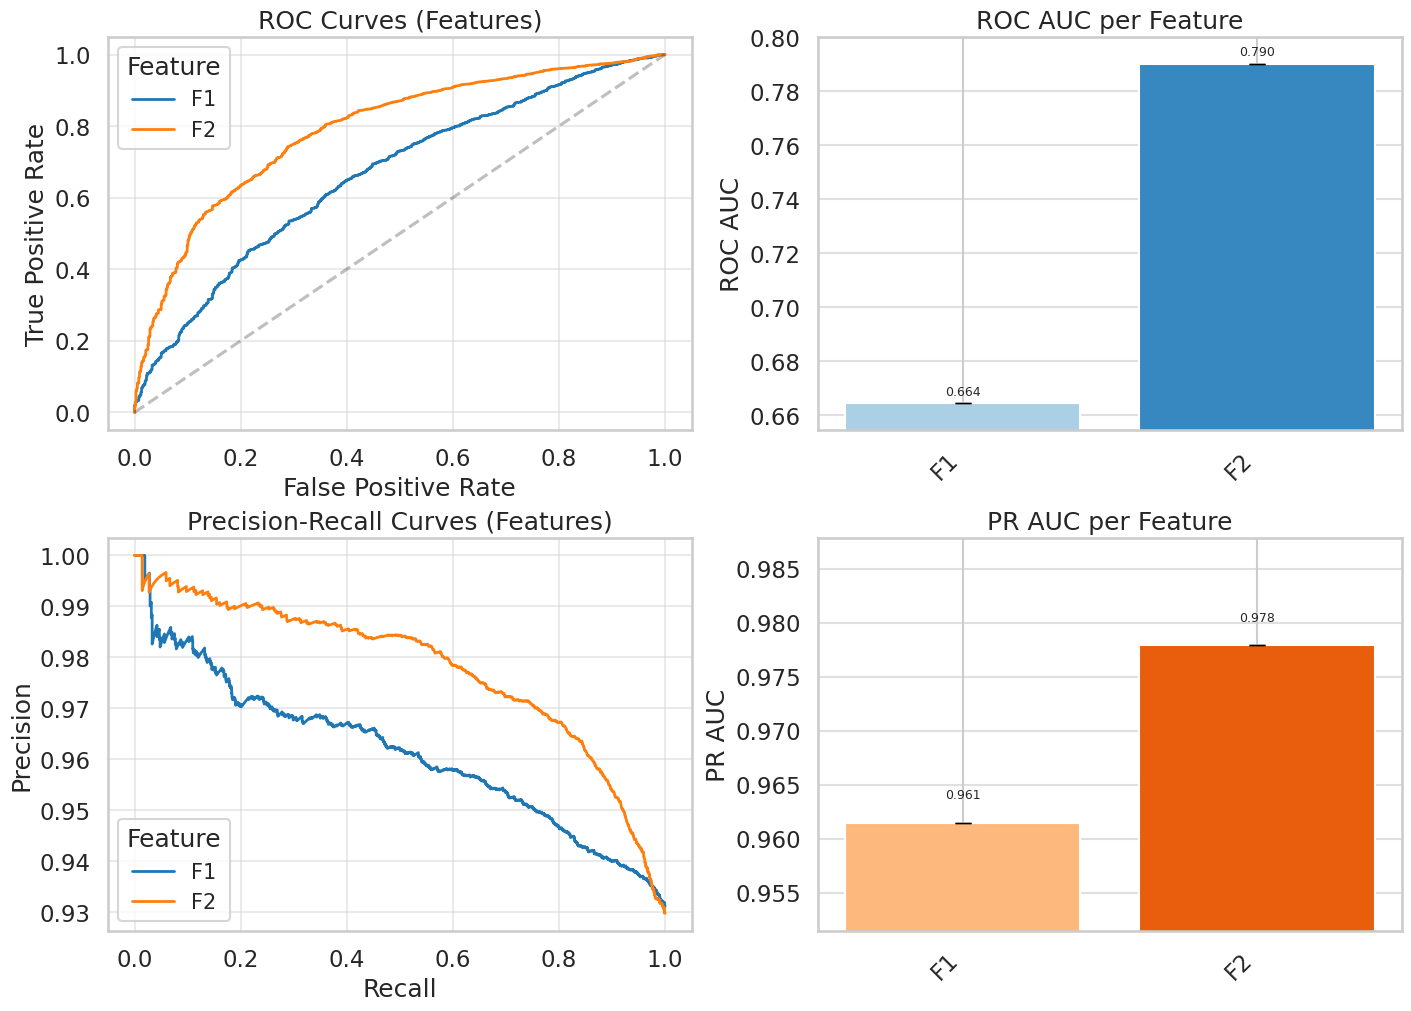

Saved feature report grid to: /home/giobbi/DDI_LLM_repo/DDI_with_ML/analysis/analysis_results_figs/report_grid_features.png
Saved feature summary CSV to: /home/giobbi/DDI_LLM_repo/DDI_with_ML/analysis/analysis_results_figs/features_summary.csv


In [10]:

# Build short codes and legend for features
feature_short_codes = {}
feature_short_desc = {}
descriptions = []
for i, r in enumerate(feature_results):
    code = f"F{i+1}"
    feature_short_codes[r['name']] = code
    desc = f"feature={r['feature']}"
    feature_short_desc[code] = desc
    descriptions.append((code, r['name'], desc))

md = "| Code | Name | Details |\n|---|---|---|\n"
for code, name, desc in descriptions:
    md += f"| **{code}** | `{name}` | {desc} |\n"

display(Markdown("### Feature Settings Legend\n\n" + md))

# Build summary DataFrame
rows = []
for r in feature_results:
    rows.append({
        'name': r['name'],
        'short': feature_short_codes.get(r['name'], r['name']),
        'feature': r['feature'],
        'ROC_AUC_mean': r.get('ROC_AUC_mean', np.nan),
        'ROC_AUC_std': r.get('ROC_AUC_std', 0.0) if r.get('ROC_AUC_std', None) is not None else 0.0,
        'PR_AUC_mean': r.get('PR_AUC_mean', np.nan),
        'PR_AUC_std': r.get('PR_AUC_std', 0.0) if r.get('PR_AUC_std', None) is not None else 0.0,
        'precision': r.get('precision'),
        'recall': r.get('recall'),
        'fpr': r.get('fpr'),
        'tpr': r.get('tpr'),
    })

feature_df = pd.DataFrame(rows)
feature_df = feature_df.sort_values('short')

# Create figure directory
fig_dir = os.path.join(os.getcwd(), 'analysis_results_figs')
os.makedirs(fig_dir, exist_ok=True)

labels = feature_df['short'].to_list()
indices = np.arange(len(labels))

# Helper from above
def compute_ylim_with_offset(means, errs=None, min_range=0.03):
    means = np.asarray(means, dtype=float)
    errs = np.zeros_like(means) if errs is None else np.asarray(errs, dtype=float)
    valid = ~np.isnan(means)
    if not valid.any():
        return 0.0, 1.0
    min_val = np.nanmin(means[valid] - errs[valid])
    max_val = np.nanmax(means[valid] + errs[valid])
    data_range = max_val - min_val
    margin = max(0.01, 0.06 * data_range)
    lower = max(0.0, min_val - margin)
    upper = min(1.0, max_val + margin)
    if (upper - lower) < min_range:
        upper = min(1.0, lower + min_range)
        lower = max(0.0, upper - min_range)
    return lower, upper

roc_means = feature_df['ROC_AUC_mean'].to_numpy(dtype=float)
roc_err = feature_df['ROC_AUC_std'].to_numpy(dtype=float)
pr_means = feature_df['PR_AUC_mean'].to_numpy(dtype=float)
pr_err = feature_df['PR_AUC_std'].to_numpy(dtype=float)

roc_low, roc_hi = compute_ylim_with_offset(roc_means, roc_err)
pr_low, pr_hi = compute_ylim_with_offset(pr_means, pr_err)

# Plot 2x2 grid for features
fig, axes = plt.subplots(2,2, figsize=(14,10), constrained_layout=True)
(ax_roc_curve, ax_roc_bar), (ax_pr_curve, ax_pr_bar) = axes

for _, row in feature_df.iterrows():
    short = row['short']
    mask = [r for r in feature_results if feature_short_codes.get(r['name']) == short]
    if mask:
        r = mask[0]
        ax_roc_curve.plot(r['fpr'], r['tpr'], label=short, linewidth=2)
ax_roc_curve.plot([0,1],[0,1],'k--', alpha=0.25)
ax_roc_curve.set_title('ROC Curves (Features)')
ax_roc_curve.set_xlabel('False Positive Rate')
ax_roc_curve.set_ylabel('True Positive Rate')
ax_roc_curve.grid(alpha=0.4)
ax_roc_curve.legend(title='Feature', fontsize='small')

bars_roc = ax_roc_bar.bar(indices, roc_means, yerr=roc_err, capsize=6, color=sns.color_palette('Blues', n_colors=len(labels)))
ax_roc_bar.set_xticks(indices)
ax_roc_bar.set_xticklabels(labels, rotation=45, ha='right')
ax_roc_bar.set_ylim(roc_low, roc_hi)
ax_roc_bar.set_title('ROC AUC per Feature')
ax_roc_bar.set_ylabel('ROC AUC')
ax_roc_bar.grid(axis='y', alpha=0.6)
for rect in bars_roc:
    h = rect.get_height()
    ax_roc_bar.text(rect.get_x() + rect.get_width()/2., h + 0.002, f"{h:.3f}", ha='center', va='bottom', fontsize=9)

for _, row in feature_df.iterrows():
    short = row['short']
    mask = [r for r in feature_results if feature_short_codes.get(r['name']) == short]
    if mask:
        r = mask[0]
        ax_pr_curve.plot(r['recall'], r['precision'], label=short, linewidth=2)
ax_pr_curve.set_title('Precision-Recall Curves (Features)')
ax_pr_curve.set_xlabel('Recall')
ax_pr_curve.set_ylabel('Precision')
ax_pr_curve.grid(alpha=0.4)
ax_pr_curve.legend(title='Feature', fontsize='small', loc='lower left')

bars_pr = ax_pr_bar.bar(indices, pr_means, yerr=pr_err, capsize=6, color=sns.color_palette('Oranges', n_colors=len(labels)))
ax_pr_bar.set_xticks(indices)
ax_pr_bar.set_xticklabels(labels, rotation=45, ha='right')
ax_pr_bar.set_ylim(pr_low, pr_hi)
ax_pr_bar.set_title('PR AUC per Feature')
ax_pr_bar.set_ylabel('PR AUC')
ax_pr_bar.grid(axis='y', alpha=0.6)
for rect in bars_pr:
    h = rect.get_height()
    ax_pr_bar.text(rect.get_x() + rect.get_width()/2., h + 0.002, f"{h:.3f}", ha='center', va='bottom', fontsize=9)

report_path = os.path.join(fig_dir, 'report_grid_features.png')
fig.savefig(report_path, dpi=180)
plt.show()
print(f"Saved feature report grid to: {report_path}")

# Save summary CSV
summary_csv = os.path.join(fig_dir, 'features_summary.csv')
feature_df.to_csv(summary_csv, index=False)
print(f"Saved feature summary CSV to: {summary_csv}")


- Strong learning signal by using description embedding of drugs using the GPT model.

## Analysis of trained model

- analysis of drug class
- visualizations
- 

In [4]:
import warnings
import logging

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
from sklearn.manifold import TSNE
from sklearn.metrics import (
    PrecisionRecallDisplay,
    precision_recall_curve,
    confusion_matrix,
    f1_score,
    RocCurveDisplay,
    roc_curve,
)

import plotly.express as px

from ddi_graph_neural_network.train_model import main
from ddi_graph_neural_network.config import Config, LossType


warnings.simplefilter(action="ignore", category=FutureWarning)

pd.set_option('display.max_rows', 100)
pd.set_option('display.max_columns', 50)

In [5]:
import os
os.environ['OMP_NUM_THREADS']='1'
os.environ['OPENBLAS_NUM_THREADS']='1'
os.environ['MKL_NUM_THREADS']='1'
import torch
torch.set_num_threads(1)
torch.set_num_interop_threads(1)

In [6]:
logging.basicConfig(level=logging.DEBUG, format="%(asctime)s - %(levelname)s - %(message)s")
logging.getLogger().setLevel(logging.DEBUG)

config = Config()

config.training.seed = 42
config.graph.seed_graph_sampling = 41
config.graph.current_graph = "DrugBank_CRESCENDDI"
config.run.take_negative_samples = True
config.run.loss_type = LossType.WeightedBCEWithLogitsLoss
config.run.pos_loss_multiplier = 0.5
config.run.upsample_negative_labels = False
config.run.use_only_sampled_negatives_in_train = False
config.graph.feature = "DESC_GPT"

config.training.repetitions = 1

In [7]:
run = main(config)

2026-04-20 08:55:40,543 - DEBUG - Loading CSV graph: DrugBank_CRESCENDDI
2026-04-20 08:55:44,340 - DEBUG - Graph and Embeddings Intersection Summary:
Number of drugs in graph: 1516, 
Number of embedding drugs in graph: 1516, 
Number of drugs dropped from graph (not in embeddings): 23, 
Number of embedding drugs not in graph: 7207
Kept percentage of embedding drugs not in graph: 0.0%, 

2026-04-20 08:55:44,478 - DEBUG - Final graph has 1516 nodes and 53892 edges.
Positive edges: 50108, 
Negative edges: 3784
2026-04-20 08:55:44,480 - DEBUG - Run 1/1 for DESC_GPT | LR: 0.0003
2026-04-20 08:55:44,541 - DEBUG - Using imbalanced loss with pos_weight: 0.0378


======== DESC_GPT ========


2026-04-20 08:56:16,425 - DEBUG - Early stopping at epoch 25


-------------------------------
-- FINAL RESULTS FOR GRAPH DrugBank_CRESCENDDI | FEATURE DESC_GPT -- 
Graph Data:  DrugBank_CRESCENDDI
ROC_AUC: 0.7901
PR_AUC: 0.9779


###

In [8]:
def find_balanced_threshold(y_scores):
    """
    Choose a threshold so that the number of predicted positives
    (y_scores >= threshold) is as close as possible to the number
    of predicted negatives (y_scores < threshold).
    """
    y_scores = np.asarray(y_scores).ravel()
    return float(np.median(y_scores))

def find_f1_optimal_threshold(y_true, y_scores):
    precisions, recalls, thresholds = precision_recall_curve(y_true, y_scores)
    f1_scores = 2 * (precisions * recalls) / (precisions + recalls)

    optimal_idx = f1_scores.argmax()
    current_threshold = thresholds[optimal_idx]
    return current_threshold

In [9]:
test_data = run["test_data"]
test_scores = run["test_scores"]
node_id_map = run["node_id_map"]
reversed_node_id_map = {v: k for k, v in node_id_map.items()}

data = run["data"]
model = run["model"]


### Classifications

In [10]:
thres = find_balanced_threshold(test_scores)

In [11]:
class_map = {(1,1): 'TP', (0,0): 'TN', (1,0): 'FN', (0,1): 'FP'}
threshold = thres #find_balanced_threshold(test_scores)
    
edges_df = pd.DataFrame(test_data.edge_label_index.cpu().t()).map(lambda x: reversed_node_id_map[x])
edges_df = edges_df.rename(columns={0: "source", 1: "target"})
edges_df['gt_label'] = test_data.edge_label.cpu().numpy().astype(int)
edges_df['pred_score'] = (test_scores >= threshold).astype(int)
edges_df['pred_class'] = [class_map[(gt, pred)] for gt, pred in zip(edges_df['gt_label'], edges_df['pred_score'])]
# make bidirectional
edges_df = pd.concat([edges_df, edges_df.rename(columns={"source": "target", "target": "source"})])
edges_df = pd.concat([edges_df, pd.get_dummies(edges_df['pred_class'])], axis=1)

print(f"negative classifications: {edges_df['FN'].sum() + edges_df['TN'].sum()}")

negative classifications: 10764


In [12]:
edges_df

,source,target,gt_label,pred_score,pred_class,FN,FP,TN,TP
0,DB01100,DB06717,1,1,TP,False,False,False,True
1,DB00318,DB00715,1,1,TP,False,False,False,True
2,DB00489,DB01184,1,0,FN,True,False,False,False
3,DB00712,DB00945,1,1,TP,False,False,False,True
4,DB06216,DB06288,1,1,TP,False,False,False,True
...,...,...,...,...,...,...,...,...,...
10772,DB01235,DB01195,0,0,TN,False,False,True,False
10773,DB01591,DB00678,0,0,TN,False,False,True,False
10774,DB01211,DB00275,0,0,TN,False,False,True,False
10775,DB01076,DB00916,0,0,TN,False,False,True,False


In [13]:
edges_df = edges_df.groupby('source').sum()[['TP', 'TN', 'FP', 'FN']]
edges_df['count'] = edges_df.sum(axis=1)
edges_df['perc_missclassified'] = (edges_df['FP'] + edges_df['FN']) / edges_df['count'] * 100
edges_df['balanced_error_rate'] = 0.5 * (edges_df['FP'] / (edges_df['FP'] + edges_df['TN'] + 1e-10) + edges_df['FN'] / (edges_df['TP'] + edges_df['FN'] + 1e-10))
print(f"threshold used: {threshold}")
print(f"negative classifications: {edges_df['FN'].sum() + edges_df['TN'].sum()}")

threshold used: 0.500148594379425
negative classifications: 10764


In [14]:
node_info_trained = edges_df.copy()

In [15]:
node_info_trained['perc_neg_gt'] = ( node_info_trained['FP'] + node_info_trained['TN'] ) / node_info_trained['count'] * 100


In [16]:
node_info_trained

,TP,TN,FP,FN,count,perc_missclassified,balanced_error_rate,perc_neg_gt
source,,,,,,,,
DB00005,3,0,0,2,5,40.000000,0.200000,0.000000
DB00006,0,0,0,8,8,100.000000,0.500000,0.000000
DB00007,26,0,0,14,40,35.000000,0.175000,0.000000
DB00008,1,0,0,4,5,80.000000,0.400000,0.000000
DB00009,1,2,0,23,26,88.461538,0.479167,7.692308
...,...,...,...,...,...,...,...,...
DB13867,0,12,0,0,12,0.000000,0.000000,100.000000
DB13872,0,5,0,0,5,0.000000,0.000000,100.000000
DB13879,0,1,0,0,1,0.000000,0.000000,100.000000


### Additional Features

In [17]:
# 1 Latent space embeddings t-SNE

def get_node_embeddings(model, data):
    model.eval()
    with torch.no_grad():
        node_embeddings = model.encode(data.x, data.edge_index)
    node_embeddings = node_embeddings.cpu().numpy()
    return node_embeddings


def get_reduced_embeddings(node_embeddings):
    # Initialize t-SNE with 2 components for 2D visualization
    tsne = TSNE(n_components=2)  # , random_state=42) # 42

    # Apply t-SNE to the drug embeddings
    reduced_embeddings = tsne.fit_transform(node_embeddings)

    return pd.DataFrame(reduced_embeddings, columns=["TSNE-1", "TSNE-2"])

latent_embeddings = get_node_embeddings(model, data)
latent_embeddings = get_reduced_embeddings(latent_embeddings)
latent_embeddings.index = latent_embeddings.index.map(lambda x: reversed_node_id_map.get(int(x), f"unknown_{int(x)}"))


In [18]:
# 2 Original embedding t-SNE

# use original embedding if disered
path = "/data/giobbi/embeddings/DESC_GPT.csv"
original_embedding = pd.read_csv(path, sep="\t", index_col=0)
original_embedding.set_index(original_embedding.columns[0], inplace=True)

# make tsne
original_embedding.select_dtypes(include=["float64", "float32"])
tsne = TSNE(n_components=2)
reduced_original_embedding = tsne.fit_transform(original_embedding.select_dtypes(include=["float64", "float32"]))
reduced_original_embedding_df = pd.DataFrame(reduced_original_embedding, columns=["TSNE-1", "TSNE-2"])
reduced_original_embedding_df.index = original_embedding.index

In [19]:
# 3 ATC classes
feature_path = "/data/giobbi/embeddings/not_aligned_with_model/drug_description_enriched_atc.csv"
additional_description_features = pd.read_csv(feature_path, sep="\t", index_col=0)
additional_description_features['atc_class_lvl_1'] = additional_description_features['atc_class_lvl_1'].apply(lambda x: x.split(': ')[-1] if pd.notna(x) else x)

In [20]:
additional_description_features

,Drug ID,Drug Name,Discription,Description_Masked,drug_unique_count,drug_count,pharma_class,drug_name,atc_match,atc_class_lvl_1
0,DB00736,Esomeprazole,"Esomeprazole, sold under the brand name Nexium...","<DRUG>, sold under the brand name Nexium, is a...",9,13,8,esomeprazole,Esomeprazole,ALIMENTARY TRACT AND METABOLISM DRUGS
1,DB01026,Ketoconazole,Ketoconazole is an imidazole antifungal agent ...,<DRUG> is an imidazole antifungal agent used i...,9,13,1,ketoconazole,Ketoconazole,"SYSTEMIC HORMONAL PREPARATIONS, EXCL. SEX HORM..."
2,DB01026,Ketoconazole,Ketoconazole is an imidazole antifungal agent ...,<DRUG> is an imidazole antifungal agent used i...,9,13,1,ketoconazole,Ketoconazole,ANTIINFECTIVES FOR SYSTEMIC USE
3,DB01026,Ketoconazole,Ketoconazole is an imidazole antifungal agent ...,<DRUG> is an imidazole antifungal agent used i...,9,13,1,ketoconazole,Ketoconazole,GENITO URINARY SYSTEM AND SEX HORMONES
4,DB01026,Ketoconazole,Ketoconazole is an imidazole antifungal agent ...,<DRUG> is an imidazole antifungal agent used i...,9,13,1,ketoconazole,Ketoconazole,DERMATOLOGICALS
...,...,...,...,...,...,...,...,...,...,...
1881,DB00276,Amsacrine,Aminoacridine derivative that is a potent inte...,Aminoacridine derivative that is a potent inte...,0,0,28,amsacrine,Amsacrine,ANTINEOPLASTIC AND IMMUNOMODULATING AGENTS
1882,DB00224,Indinavir,A potent and specific HIV protease inhibitor t...,A potent and specific HIV protease inhibitor t...,0,0,4,indinavir,Indinavir,ANTIINFECTIVES FOR SYSTEMIC USE
1883,DB00229,Cefotiam,One of the cephalosporins that has a broad spe...,One of the cephalosporins that has a broad spe...,0,0,3,cefotiam,Cefotiam,ANTIINFECTIVES FOR SYSTEMIC USE
1884,DB00242,Cladribine,An antineoplastic agent used in the treatment ...,An antineoplastic agent used in the treatment ...,0,0,5,cladribine,Cladribine,ANTINEOPLASTIC AND IMMUNOMODULATING AGENTS


In [21]:
embedding = reduced_original_embedding_df

embedding = embedding.merge(latent_embeddings, left_index=True, right_index=True, suffixes=('_input', '_latent'))

# Now join the additional features
embedding = embedding.join(
    additional_description_features.set_index("Drug ID"),
    how="left",
)

embedding = embedding.join(
    node_info_trained[["perc_missclassified", "balanced_error_rate", "count", "perc_neg_gt"]].rename(columns={
        "count": "edge_count",
    }),
    how="left",
)



In [22]:
embedding['pharma_class'], class_mapping = pd.factorize(embedding['atc_class_lvl_1'].fillna("Unknown"))
# get mapping of number to class name
num_to_class = {num: cls for num, cls in enumerate(class_mapping)}
print(num_to_class)

{0: 'ANTINEOPLASTIC AND IMMUNOMODULATING AGENTS', 1: 'BLOOD AND BLOOD FORMING ORGAN DRUGS', 2: 'Unknown', 3: 'SENSORY ORGAN DRUGS', 4: 'ALIMENTARY TRACT AND METABOLISM DRUGS', 5: 'SYSTEMIC HORMONAL PREPARATIONS, EXCL. SEX HORMONES AND INSULINS', 6: 'VARIOUS DRUG CLASSES IN ATC', 7: 'RESPIRATORY SYSTEM DRUGS', 8: 'MUSCULO-SKELETAL SYSTEM DRUGS', 9: 'ANTIINFECTIVES FOR SYSTEMIC USE', 10: 'GENITO URINARY SYSTEM AND SEX HORMONES', 11: 'DERMATOLOGICALS', 12: 'NERVOUS SYSTEM DRUGS', 13: 'CARDIOVASCULAR SYSTEM DRUGS', 14: 'ANTIPARASITIC PRODUCTS, INSECTICIDES AND REPELLENTS'}


In [23]:
pd.DataFrame({'class': class_mapping})

,class
0,ANTINEOPLASTIC AND IMMUNOMODULATING AGENTS
1,BLOOD AND BLOOD FORMING ORGAN DRUGS
2,Unknown
3,SENSORY ORGAN DRUGS
4,ALIMENTARY TRACT AND METABOLISM DRUGS
5,"SYSTEMIC HORMONAL PREPARATIONS, EXCL. SEX HORM..."
6,VARIOUS DRUG CLASSES IN ATC
7,RESPIRATORY SYSTEM DRUGS
8,MUSCULO-SKELETAL SYSTEM DRUGS
9,ANTIINFECTIVES FOR SYSTEMIC USE


Total pharma classes: 15
Sample sizes (top 10):


pharma_label
NERVOUS SYSTEM DRUGS                          262
Unknown                                       230
ANTINEOPLASTIC AND IMMUNOMODULATING AGENTS    189
ANTIINFECTIVES FOR SYSTEMIC USE               183
CARDIOVASCULAR SYSTEM DRUGS                   176
ALIMENTARY TRACT AND METABOLISM DRUGS         174
SENSORY ORGAN DRUGS                           135
DERMATOLOGICALS                               113
RESPIRATORY SYSTEM DRUGS                      113
GENITO URINARY SYSTEM AND SEX HORMONES         89
Name: count, dtype: int64

Classes with n>=10: 15: ['NERVOUS SYSTEM DRUGS', 'Unknown', 'ANTINEOPLASTIC AND IMMUNOMODULATING AGENTS', 'ANTIINFECTIVES FOR SYSTEMIC USE', 'CARDIOVASCULAR SYSTEM DRUGS', 'ALIMENTARY TRACT AND METABOLISM DRUGS', 'SENSORY ORGAN DRUGS', 'DERMATOLOGICALS', 'RESPIRATORY SYSTEM DRUGS', 'GENITO URINARY SYSTEM AND SEX HORMONES', 'MUSCULO-SKELETAL SYSTEM DRUGS', 'BLOOD AND BLOOD FORMING ORGAN DRUGS', 'VARIOUS DRUG CLASSES IN ATC', 'SYSTEMIC HORMONAL PREPARATIONS, EXCL. SEX HORMONES AND INSULINS', 'ANTIPARASITIC PRODUCTS, INSECTICIDES AND REPELLENTS']
Kruskal-Wallis H=196.9794, p=2.2723e-34, epsilon-sq=0.1101
Running pairwise tests for classes (limited): ['NERVOUS SYSTEM DRUGS', 'Unknown', 'ANTINEOPLASTIC AND IMMUNOMODULATING AGENTS', 'ANTIINFECTIVES FOR SYSTEMIC USE', 'CARDIOVASCULAR SYSTEM DRUGS', 'ALIMENTARY TRACT AND METABOLISM DRUGS']

Top significant pairs (BH-corrected):


,class1,class2,u_stat,p_value,n1,n2,mean1,mean2,significant_bh
1,NERVOUS SYSTEM DRUGS,ANTINEOPLASTIC AND IMMUNOMODULATING AGENTS,10818.0,1.359790e-19,250,176,40.943854,72.133105,True
0,NERVOUS SYSTEM DRUGS,Unknown,12235.0,3.398687e-17,250,183,40.943854,73.803819,True
2,NERVOUS SYSTEM DRUGS,ANTIINFECTIVES FOR SYSTEMIC USE,9780.5,4.424821e-16,250,150,40.943854,71.994844,True
4,NERVOUS SYSTEM DRUGS,ALIMENTARY TRACT AND METABOLISM DRUGS,12073.5,4.402117e-12,250,161,40.943854,66.521739,True
3,NERVOUS SYSTEM DRUGS,CARDIOVASCULAR SYSTEM DRUGS,13733.0,4.329687e-09,250,166,40.943854,58.568627,True
7,Unknown,CARDIOVASCULAR SYSTEM DRUGS,19227.0,8.500247e-06,183,166,73.803819,58.568627,True
10,ANTINEOPLASTIC AND IMMUNOMODULATING AGENTS,CARDIOVASCULAR SYSTEM DRUGS,18227.0,4.845631e-05,176,166,72.133105,58.568627,True
12,ANTIINFECTIVES FOR SYSTEMIC USE,CARDIOVASCULAR SYSTEM DRUGS,15515.5,1.001915e-04,150,166,71.994844,58.568627,True
14,CARDIOVASCULAR SYSTEM DRUGS,ALIMENTARY TRACT AND METABOLISM DRUGS,11494.5,2.551635e-02,166,161,58.568627,66.521739,True



Summary for all classes (top 20 shown):


,class,n,median,IQR,mean,std
0,NERVOUS SYSTEM DRUGS,250,30.980392,45.212932,40.943854,33.025149
1,Unknown,183,100.000000,50.000000,73.803819,35.125702
2,ANTINEOPLASTIC AND IMMUNOMODULATING AGENTS,176,85.714286,56.473214,72.133105,30.385170
4,CARDIOVASCULAR SYSTEM DRUGS,166,50.000000,67.428571,58.568627,30.777006
5,ALIMENTARY TRACT AND METABOLISM DRUGS,161,75.000000,65.000000,66.521739,34.553192
3,ANTIINFECTIVES FOR SYSTEMIC USE,150,100.000000,60.000000,71.994844,33.206913
6,SENSORY ORGAN DRUGS,119,65.000000,68.750000,62.055825,33.773651
8,RESPIRATORY SYSTEM DRUGS,107,31.250000,49.776786,42.713930,35.403624
7,DERMATOLOGICALS,98,70.202020,66.666667,64.399134,35.746836
9,GENITO URINARY SYSTEM AND SEX HORMONES,75,79.166667,54.444444,72.388254,28.875276


2026-04-20 08:57:32,377 - DEBUG - Loaded backend module://matplotlib_inline.backend_inline version unknown.
2026-04-20 08:57:32,379 - DEBUG - Loaded backend module://matplotlib_inline.backend_inline version unknown.
2026-04-20 08:57:32,391 - DEBUG - findfont: Matching sans\-serif:style=normal:variant=normal:weight=normal:stretch=normal:size=10.0.
2026-04-20 08:57:32,392 - DEBUG - findfont: score(FontEntry(fname='/home/giobbi/DDI_LLM_repo/DDI_with_ML/.venv/lib/python3.10/site-packages/matplotlib/mpl-data/fonts/ttf/STIXNonUniBol.ttf', name='STIXNonUnicode', style='normal', variant='normal', weight=700, stretch='normal', size='scalable')) = 10.335
2026-04-20 08:57:32,393 - DEBUG - findfont: score(FontEntry(fname='/home/giobbi/DDI_LLM_repo/DDI_with_ML/.venv/lib/python3.10/site-packages/matplotlib/mpl-data/fonts/ttf/STIXGeneral.ttf', name='STIXGeneral', style='normal', variant='normal', weight=400, stretch='normal', size='scalable')) = 10.05
2026-04-20 08:57:32,394 - DEBUG - findfont: score

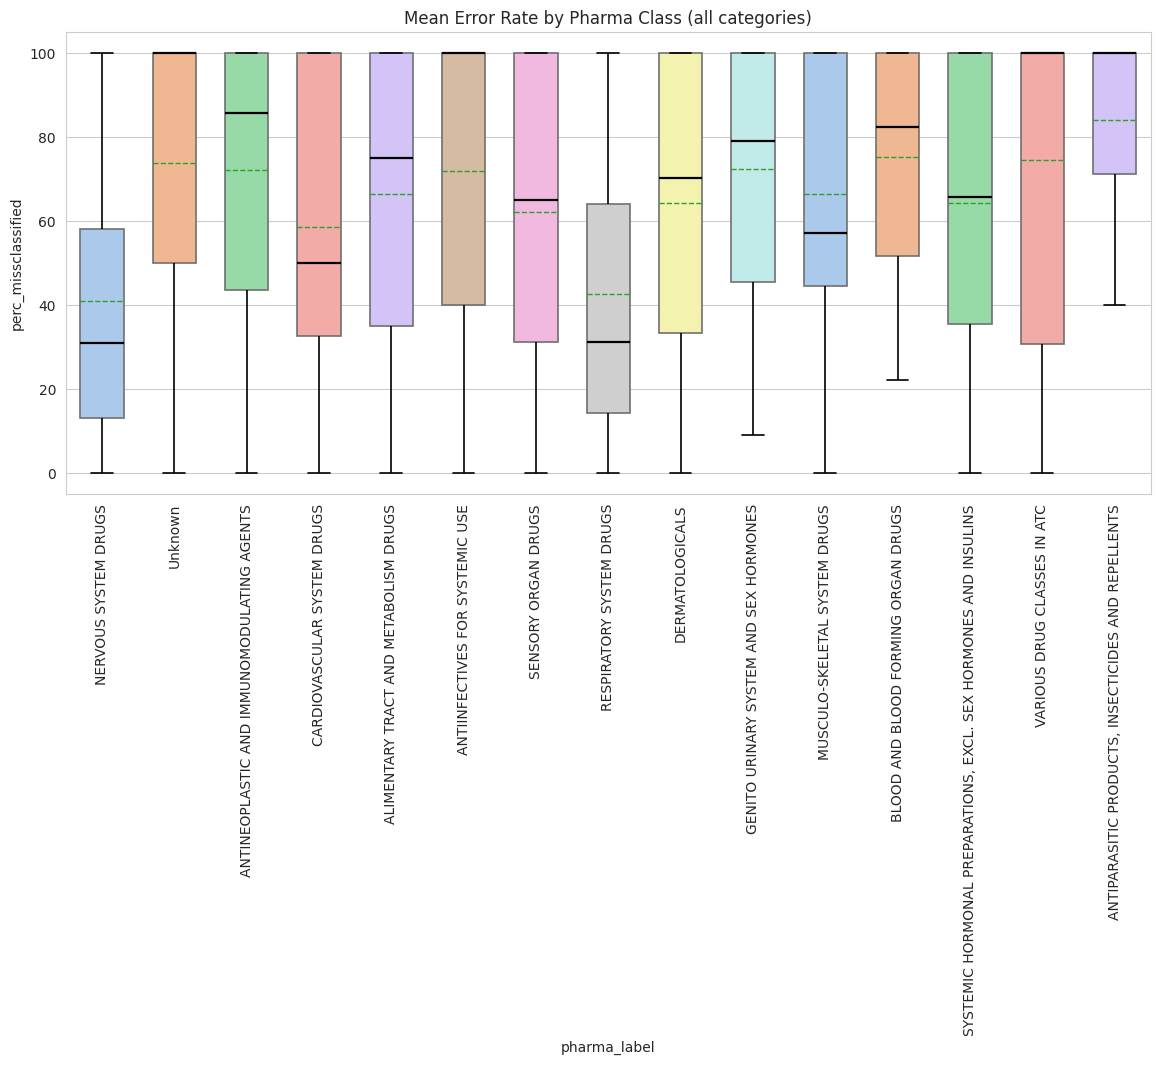

Figure saved: pharma_class_all_categories.png
Summary CSV saved: pharma_class_summary_all.csv


In [24]:
# Simplified pharma-class analysis (keep all categories; tests use MIN_N)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import kruskal, mannwhitneyu
from itertools import combinations

# Parameters
MIN_N = 10
MAX_PAIRWISE_CLASSES = 6  # limit number of classes for pairwise tests
error_rate = 'perc_missclassified' #'balanced_error_rate'

# Prepare labels (keep all original categories)
df_simple = embedding.copy()
df_simple['pharma_label'] = df_simple['atc_class_lvl_1'].fillna('Unknown')
counts = df_simple['pharma_label'].value_counts()
all_classes = counts.index.tolist()

print(f'Total pharma classes: {len(all_classes)}')
print('Sample sizes (top 10):')
display(counts.head(10))

# Prepare groups for statistical testing (only classes with enough samples)
groups = []
group_names = []
for name in all_classes:
    arr = pd.to_numeric(df_simple.loc[df_simple['pharma_label'] == name, error_rate], errors='coerce').dropna().values
    if len(arr) >= MIN_N:
        groups.append(arr)
        group_names.append(name)

print(f'Classes with n>={MIN_N}: {len(group_names)}: {group_names}')
if len(group_names) < 2:
    print('Not enough groups with sufficient sample size for omnibus test.')
else:
    # Omnibus non-parametric test
    kw_stat, kw_p = kruskal(*groups)
    total_n = sum(len(g) for g in groups)
    try:
        eps_sq = max(0.0, (kw_stat - (len(groups) - 1)) / (total_n - len(groups))) if total_n > len(groups) else np.nan
    except Exception:
        eps_sq = np.nan
    print(f'Kruskal-Wallis H={kw_stat:.4f}, p={kw_p:.4e}, epsilon-sq={eps_sq:.4f}')

    # Pairwise tests limited to top classes by size to reduce multiplicity
    size_order = counts.loc[group_names].sort_values(ascending=False)
    candidate_classes = size_order.index.tolist()[:MAX_PAIRWISE_CLASSES]
    print(f'Running pairwise tests for classes (limited): {candidate_classes}')

    pair_results = []
    pvals = []
    for a, b in combinations(candidate_classes, 2):
        ga = pd.to_numeric(df_simple.loc[df_simple['pharma_label'] == a, error_rate], errors='coerce').dropna().values
        gb = pd.to_numeric(df_simple.loc[df_simple['pharma_label'] == b, error_rate], errors='coerce').dropna().values
        if len(ga) < 2 or len(gb) < 2:
            continue
        stat, p = mannwhitneyu(ga, gb, alternative='two-sided')
        pair_results.append({'class1': a, 'class2': b, 'u_stat': float(stat), 'p_value': float(p), 'n1': len(ga), 'n2': len(gb), 'mean1': float(np.mean(ga)), 'mean2': float(np.mean(gb))})
        pvals.append(p)

    # Benjamini-Hochberg (FDR) correction
    def bh_significant(pvals, alpha=0.05):
        p = np.array(pvals)
        n = len(p)
        if n == 0:
            return np.array([], dtype=bool)
        order = np.argsort(p)
        ranks = np.arange(1, n+1)
        thresh = ranks * alpha / n
        sorted_p = p[order]
        below = sorted_p <= thresh
        if not np.any(below):
            return np.zeros(n, dtype=bool)
        max_i = np.max(np.where(below)[0])
        cutoff = thresh[max_i]
        return p <= cutoff

    sig_mask = bh_significant(pvals, alpha=0.05) if len(pvals) > 0 else []
    for i, res in enumerate(pair_results):
        res['significant_bh'] = bool(sig_mask[i]) if len(sig_mask) > 0 else False

    pair_df = pd.DataFrame(pair_results).sort_values('p_value') if pair_results else pd.DataFrame()
    if not pair_df.empty:
        print('\nTop significant pairs (BH-corrected):')
        display(pair_df.loc[pair_df['significant_bh']].head(10))
    else:
        print('\nNo pairwise tests run (insufficient classes or small sample sizes).')

# Summary table for all classes (for reporting/CSV)
summary_rows = []
for name in all_classes:
    grp = pd.to_numeric(df_simple.loc[df_simple['pharma_label'] == name, error_rate], errors='coerce').dropna()
    if len(grp) == 0:
        summary_rows.append({'class': name, 'n': 0, 'median': np.nan, 'IQR': np.nan, 'mean': np.nan, 'std': np.nan})
        continue
    summary_rows.append({'class': name, 'n': len(grp), 'median': float(np.median(grp)), 'IQR': float(np.percentile(grp, 75) - np.percentile(grp, 25)), 'mean': float(np.mean(grp)), 'std': float(np.std(grp))})
summary_all_df = pd.DataFrame(summary_rows).sort_values('n', ascending=False)
print('\nSummary for all classes (top 20 shown):')
display(summary_all_df.head(20))

# Plot: include all classes (ordered by sample size)
sns.set_style('whitegrid')
plt.figure(figsize=(14,6))
plot_df = df_simple.copy().reset_index(drop=True)
order = summary_all_df['class'].tolist()
order = [c for c in order if c in plot_df['pharma_label'].unique()]
# Use a categorical palette sized to number of classes (fallback to default if too large)
try:
    # Use a modern, vibrant categorical palette for up to 12 classes, else fall back to tab20
    palette = sns.color_palette('pastel',n_colors=len(order))   
except Exception:
    palette = sns.color_palette('husl', n_colors=min(len(order), 12))
try:
    sns.boxplot(
        data=plot_df, x='pharma_label', y=error_rate, order=order,
        width=0.6, showcaps=True, showfliers=False, palette=palette, linewidth=1.2,
        showmeans=True, meanline=True,
        medianprops={'linewidth': 1.6, 'color': 'black'},
        #meanprops={'color': 'black', 'linestyle': '-', 'linewidth': 1.6},
        whiskerprops={'linewidth': 1.2, 'color': 'black'},
        capprops={'linewidth': 1.2, 'color': 'black'},
    )
except Exception as e:
    print('Boxplot failed, falling back to simple boxplot:', e)
    sns.boxplot(data=plot_df, x='pharma_label', y=error_rate, order=order, palette=palette)
plt.xticks(rotation=90)
plt.title('Mean Error Rate by Pharma Class (all categories)')
plt.tight_layout()
fig_path = 'pharma_class_all_categories.png'
plt.savefig(fig_path, dpi=200, bbox_inches='tight')
plt.show()
print(f'Figure saved: {fig_path}')

# Save summary CSV for all classes
summary_csv = 'pharma_class_summary_all.csv'
summary_all_df.to_csv(summary_csv, index=False)
print(f'Summary CSV saved: {summary_csv}')

### Pharma-class analysis — Interpretation and implications

- **Practical / scientific implications:**

  - The model's `balanced_error_rate` is heterogeneous across `atc_class_lvl_1` categories: some classes are consistently easier or harder for the model.
  - The effect size (~10%) is modest — class membership explains part of the variance but there remains substantial overlap between distributions.

- **Possible causes to investigate:**

  - Data imbalance: uneven sample counts give larger classes more training signal.
  - Domain / feature gaps: classes may differ in chemical diversity or representation in feature space.
  - Label quality: some classes may contain noisier or ambiguous labels, increasing error rates.

- **Recommended next steps (actionable):**

  - Run per‑class diagnostics: mean `balanced_error_rate`, counts, confusion matrices, and calibration plots (see `pharma_class_summary_all.csv`).
  - Try remediation experiments: stratified sampling, class reweighting, targeted augmentation, or class‑specific models.
  - Fit a regression or mixed‑effects model including sample size and covariates to quantify class effects while controlling confounders.


### Visualizations

In [26]:
embedding

,TSNE-1_input,TSNE-2_input,TSNE-1_latent,TSNE-2_latent,Drug Name,Discription,Description_Masked,drug_unique_count,drug_count,pharma_class,drug_name,atc_match,atc_class_lvl_1,perc_missclassified,balanced_error_rate,edge_count,perc_neg_gt
DB00005,25.850260,-42.142303,-12.219755,-33.801872,Etanercept,Dimeric fusion protein consisting of the extra...,Dimeric fusion protein consisting of the extra...,2,3,0,etanercept,Etanercept,ANTINEOPLASTIC AND IMMUNOMODULATING AGENTS,40.000000,0.200000,5.0,0.000000
DB00006,0.375309,-38.535625,19.432455,-39.822010,Bivalirudin,Bivalirudin is a synthetic 20 residue peptide ...,<DRUG> is a synthetic 20 residue peptide (<DRU...,2,4,1,bivalirudin,Bivalirudin,BLOOD AND BLOOD FORMING ORGAN DRUGS,100.000000,0.500000,8.0,0.000000
DB00007,49.671875,46.503342,51.728455,14.104576,Leuprolide,Leuprolide is a synthetic 9-residue peptide an...,<DRUG> is a synthetic 9-residue peptide analog...,1,4,2,leuprolide,NaN,NaN,35.000000,0.175000,40.0,0.000000
DB00008,3.455103,-56.713684,6.162561,-26.614265,Peginterferon alfa-2a,Peginterferon alfa-2a is a form of recombinant...,<DRUG> is a form of recombinant interferon use...,1,5,2,peginterferon alfa-2a,NaN,NaN,80.000000,0.400000,5.0,0.000000
DB00009,-4.245230,-40.691662,20.169132,-40.205963,Alteplase,Alteplase is a recombinant tissue plasminogen ...,<DRUG> is a recombinant tissue <DRUG> activato...,6,14,1,alteplase,Alteplase,BLOOD AND BLOOD FORMING ORGAN DRUGS,88.461538,0.479167,26.0,7.692308
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
DB00781,-35.181358,-41.426025,-17.041256,19.723574,Polymyxin B,Polymyxin B was discovered in the 1940s[A17642...,<DRUG> was discovered in the 1940s[A176429]. T...,2,4,3,polymyxin b,Polymyxin b,SENSORY ORGAN DRUGS,100.000000,0.500000,1.0,0.000000
DB00781,-35.181358,-41.426025,-17.041256,19.723574,Polymyxin B,Polymyxin B was discovered in the 1940s[A17642...,<DRUG> was discovered in the 1940s[A176429]. T...,2,4,3,polymyxin b,Polymyxin b,SENSORY ORGAN DRUGS,100.000000,0.500000,1.0,0.000000
DB00781,-35.181358,-41.426025,-17.041256,19.723574,Polymyxin B,Polymyxin B was discovered in the 1940s[A17642...,<DRUG> was discovered in the 1940s[A176429]. T...,2,4,4,polymyxin b,Polymyxin b,ALIMENTARY TRACT AND METABOLISM DRUGS,100.000000,0.500000,1.0,0.000000
DB00781,-35.181358,-41.426025,-17.041256,19.723574,Polymyxin B,Polymyxin B was discovered in the 1940s[A17642...,<DRUG> was discovered in the 1940s[A176429]. T...,2,4,3,polymyxin b,Polymyxin b,SENSORY ORGAN DRUGS,100.000000,0.500000,1.0,0.000000


In [31]:
def format_description(desc, max_length=60):
    # Insert <br> every max_length characters, or at sentence breaks
    import re

    if pd.isnull(desc):
        return ""
    # split every 20 characters
    sentences = re.findall(".{1,%d}" % max_length, desc)
    return "<br>".join(sentences)

hovertemplate = (
    "Drug ID: %{text}"
    "<br>TSNE-1: %{x:.3f}"
    "<br>TSNE-2: %{y:.3f}"
    "<br>Drug Count: %{customdata[0]}"
    "<br>Pharma Class: %{customdata[1]}"
    "<br>Description: %{customdata[2]}"
    "<extra></extra>"
)

In [43]:
edge_label = test_data.edge_label.cpu().numpy()
predicted_labels = (test_scores >= threshold).astype(int)
edge_pairs = test_data.edge_label_index.cpu().t().numpy()

In [44]:
embedding

,TSNE-1_input,TSNE-2_input,TSNE-1_latent,TSNE-2_latent,Drug Name,Discription,Description_Masked,drug_unique_count,drug_count,pharma_class,drug_name,atc_match,atc_class_lvl_1,perc_missclassified,balanced_error_rate,edge_count,perc_neg_gt,Description_br
DB00005,25.850260,-42.142303,-12.219755,-33.801872,Etanercept,Dimeric fusion protein consisting of the extra...,Dimeric fusion protein consisting of the extra...,2,3,0,etanercept,Etanercept,ANTINEOPLASTIC AND IMMUNOMODULATING AGENTS,40.000000,0.200000,5.0,0.000000,Dimeric fusion protein consisting of the extra...
DB00006,0.375309,-38.535625,19.432455,-39.822010,Bivalirudin,Bivalirudin is a synthetic 20 residue peptide ...,<DRUG> is a synthetic 20 residue peptide (<DRU...,2,4,1,bivalirudin,Bivalirudin,BLOOD AND BLOOD FORMING ORGAN DRUGS,100.000000,0.500000,8.0,0.000000,Bivalirudin is a synthetic 20 residue peptide ...
DB00007,49.671875,46.503342,51.728455,14.104576,Leuprolide,Leuprolide is a synthetic 9-residue peptide an...,<DRUG> is a synthetic 9-residue peptide analog...,1,4,2,leuprolide,NaN,NaN,35.000000,0.175000,40.0,0.000000,Leuprolide is a synthetic 9-residue peptide an...
DB00008,3.455103,-56.713684,6.162561,-26.614265,Peginterferon alfa-2a,Peginterferon alfa-2a is a form of recombinant...,<DRUG> is a form of recombinant interferon use...,1,5,2,peginterferon alfa-2a,NaN,NaN,80.000000,0.400000,5.0,0.000000,Peginterferon alfa-2a is a form of recombinant...
DB00009,-4.245230,-40.691662,20.169132,-40.205963,Alteplase,Alteplase is a recombinant tissue plasminogen ...,<DRUG> is a recombinant tissue <DRUG> activato...,6,14,1,alteplase,Alteplase,BLOOD AND BLOOD FORMING ORGAN DRUGS,88.461538,0.479167,26.0,7.692308,Alteplase is a recombinant tissue plasminogen ...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
DB00781,-35.181358,-41.426025,-17.041256,19.723574,Polymyxin B,Polymyxin B was discovered in the 1940s[A17642...,<DRUG> was discovered in the 1940s[A176429]. T...,2,4,3,polymyxin b,Polymyxin b,SENSORY ORGAN DRUGS,100.000000,0.500000,1.0,0.000000,Polymyxin B was discovered in the 1940s[A17642...
DB00781,-35.181358,-41.426025,-17.041256,19.723574,Polymyxin B,Polymyxin B was discovered in the 1940s[A17642...,<DRUG> was discovered in the 1940s[A176429]. T...,2,4,3,polymyxin b,Polymyxin b,SENSORY ORGAN DRUGS,100.000000,0.500000,1.0,0.000000,Polymyxin B was discovered in the 1940s[A17642...
DB00781,-35.181358,-41.426025,-17.041256,19.723574,Polymyxin B,Polymyxin B was discovered in the 1940s[A17642...,<DRUG> was discovered in the 1940s[A176429]. T...,2,4,4,polymyxin b,Polymyxin b,ALIMENTARY TRACT AND METABOLISM DRUGS,100.000000,0.500000,1.0,0.000000,Polymyxin B was discovered in the 1940s[A17642...
DB00781,-35.181358,-41.426025,-17.041256,19.723574,Polymyxin B,Polymyxin B was discovered in the 1940s[A17642...,<DRUG> was discovered in the 1940s[A176429]. T...,2,4,3,polymyxin b,Polymyxin b,SENSORY ORGAN DRUGS,100.000000,0.500000,1.0,0.000000,Polymyxin B was discovered in the 1940s[A17642...


In [ ]:
import numpy as np
import plotly.graph_objects as go
import plotly.express as px

# ===== USER SETTINGS =====
# Set a drug ID to filter edges (e.g., "DB00005"), or None to show all edges
filter_drug_id = None  # Change this to filter, e.g., filter_drug_id = "DB00005"
tsne_setting = "input"  # or "latent"
# =========================

tsne_setting = "_" + tsne_setting if tsne_setting else ""

# Prepare embedding table for plotting
embedding["Description_br"] = embedding["Discription"].apply(format_description)
embedding["pharma_class"] = embedding["pharma_class"].fillna("Unknown")

# Color mapping
classes = embedding["pharma_class"].astype(str).unique()
palette = px.colors.qualitative.Set1
color_map = {cls: palette[i % len(palette)] for i, cls in enumerate(sorted(classes))}

fig = go.Figure()

# Add node traces grouped and colored by pharma_class
for cls in sorted(classes):
    df_cls = embedding[embedding["pharma_class"].astype(str) == cls]
    node_x = df_cls["TSNE-1" + tsne_setting].values
    node_y = df_cls["TSNE-2" + tsne_setting].values
    node_ids = df_cls.index.astype(str).tolist()
    customdata_cls = df_cls[["drug_count", "pharma_class", "Description_br"]].values

    fig.add_trace(
        go.Scattergl(
            x=node_x,
            y=node_y,
            mode="markers",
            marker=dict(size=7, color=color_map[cls]),
            text=node_ids,
            customdata=customdata_cls,
            hovertemplate=hovertemplate,
            name=f"{cls}",
        )
    )

# Robust mapping helper for edge endpoints -> embedding index key
rev_map = globals().get("reversed_node_id_map", None)  # often maps numeric id -> drug id string
node_map = globals().get("node_id_map", None)        # often maps drug id -> numeric id

def map_node_to_embedding_key(n):
    # Try direct membership
    if n in embedding.index:
        return n
    s = str(n)
    if s in embedding.index:
        return s
    # numeric fallback
    try:
        i = int(n)
        if i in embedding.index:
            return i
    except Exception:
        pass
    # reversed map: numeric id -> drug id string
    if rev_map is not None:
        try:
            k = rev_map.get(int(n))
            if k in embedding.index:
                return k
        except Exception:
            pass
    # node_map: drug id string -> numeric id (maybe embedding index is numeric)
    if node_map is not None:
        try:
            k = node_map.get(s)
            if k in embedding.index:
                return k
        except Exception:
            pass
    return None

def get_drug_id_from_node_index(node_idx):
    """Convert a numeric node index to a drug ID string."""
    if rev_map is not None:
        try:
            return rev_map.get(int(node_idx))
        except Exception:
            pass
    return None

# --- Edge lines by confusion class (TP, FN, TN, FP) ---
# gt: ground truth, pred: predicted_labels
# edge_pairs, gt, pred must be aligned

gt = np.asarray(edge_label.cpu().numpy() if hasattr(edge_label, "cpu") else edge_label).astype(int)
pred = np.asarray(predicted_labels).astype(int)
assert len(edge_pairs) == len(gt) == len(pred), "edge_pairs, gt, pred must have same length"

is_tp = (gt == 1) & (pred == 1)
is_fp = (gt == 0) & (pred == 1)
is_tn = (gt == 0) & (pred == 0)
is_fn = (gt == 1) & (pred == 0)

# Build edge traces safely with optional drug filtering
def add_edge_lines(mask, color, name, dash="solid", filter_id=None):
    xs, ys = [], []
    skipped = 0
    drawn = 0
    for (src, dst), keep in zip(edge_pairs, mask):
        if not keep:
            continue
        # Apply drug filter if specified
        if filter_id is not None:
            # Convert numeric indices to drug IDs
            src_drug_id = get_drug_id_from_node_index(src)
            dst_drug_id = get_drug_id_from_node_index(dst)
            # Only include edges where src or dst matches the filter drug
            if src_drug_id != filter_id and dst_drug_id != filter_id:
                skipped += 1
                continue
        # map endpoints to embedding keys
        key_src = map_node_to_embedding_key(src)
        key_dst = map_node_to_embedding_key(dst)
        if key_src is None or key_dst is None:
            skipped += 1
            continue
        try:
            x0, y0 = embedding.loc[key_src, ["TSNE-1" + tsne_setting, "TSNE-2" + tsne_setting]]
            x1, y1 = embedding.loc[key_dst, ["TSNE-1" + tsne_setting, "TSNE-2" + tsne_setting]]
        except Exception:
            skipped += 1
            continue
        xs += [x0, x1, None]
        ys += [y0, y1, None]
        drawn += 1
    if xs:
        fig.add_trace(
            go.Scattergl(
                x=xs,
                y=ys,
                mode="lines",
                line=dict(color=color, width=1.0, dash=dash),
                name=name,
                hoverinfo="skip",
            )
        )
    # debug info
    print(f"{name}: drawn={drawn}, skipped={skipped}")

# Add edges by confusion class with requested colors/styles
add_edge_lines(is_tp, "rgba(0,180,0,0.85)", "TP (gt=1, pred=1)", dash="solid", filter_id=filter_drug_id)
add_edge_lines(is_fn, "rgba(160,180,0,0.85)", "FN (gt=1, pred=0)", dash="dash", filter_id=filter_drug_id)
add_edge_lines(is_tn, "rgba(220,20,60,0.85)", "TN (gt=0, pred=0)", dash="solid", filter_id=filter_drug_id)
add_edge_lines(is_fp, "rgba(220,120,90,0.85)", "FP (gt=0, pred=1)", dash="dash", filter_id=filter_drug_id)

fig.update_layout(
    title=f"t-SNE: TP={np.sum(is_tp)}, TN={np.sum(is_tn)}, FP={np.sum(is_fp)}, FN={np.sum(is_fn)}" + (f" | Filter: {filter_drug_id}" if filter_drug_id else ""),
    width=950,
    height=750,
    legend=dict(itemsizing="constant"),
)
fig.show()

if filter_drug_id:
    print(f"\n✓ Edges filtered to drug: {filter_drug_id}")
else:
    print("\nShowing all edges. To filter, set filter_drug_id at the top of the cell (e.g., filter_drug_id = 'DB00005')")


# Discussion

# Open Points